In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.multitest as smm

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

from scripts.utils import loadcsv

In [2]:
def calculate_ttest_pvalues(df, group_col='Group', condition_col='Condition', value_col='Value'):
    # 获取唯一的分组和条件
    groups = df[group_col].unique()
    conditions = df[condition_col].unique()
    results = []
    
    # 对每个分组进行组内条件比较
    for group in groups:
        group_data = df[df[group_col] == group]
        
        # 提取各条件的数据
        data = [group_data[group_data[condition_col] == cond][value_col] 
                for cond in conditions]
        
        # 执行独立样本t检验
        t_stat, p_val = stats.ttest_ind(*data)
        
        # 将结果添加到列表
        results.append({
            'Group': group,
            'Comparison': f"{conditions[0]} vs {conditions[1]}",
            't-statistic': t_stat,
            'p-value': p_val
        })
        
    return pd.DataFrame(results)

In [3]:
def summarize_trend_and_pvalue(data_all, features, sick, control):
    summary = []
    stain_types = ["CTCF", "H3K27ac"]  # 强制顺序
    for feature in features:
        row = {"Description": feature.replace("_", " ").capitalize()}
        
        for stain in stain_types:
            subset = data_all[data_all["Stain_Type"] == stain]
            ctrl_vals = subset[subset["State"] == control][feature].dropna()
            sick_vals = subset[subset["State"] == sick][feature].dropna()
            
            if len(ctrl_vals) == 0 or len(sick_vals) == 0:
                row[stain] = "N/A"
                row[f"{stain}_pvalue"] = "N/A"
                continue
            
            # t 检验
            t_stat, p_val = stats.ttest_ind(ctrl_vals, sick_vals, equal_var=False)
            row[f"{stain}_pvalue"] = f"{p_val:.5e}"
            
            # 趋势方向
            diff = sick_vals.mean() - ctrl_vals.mean()
            trend = "Increased" if diff > 0 else "Decreased"
            row[stain] = trend
        
        summary.append(row)

    # 生成 DataFrame
    df = pd.DataFrame(summary)

    # 手动设置列顺序
    desired_order = ["Description", "CTCF", "H3K27ac", "CTCF_pvalue", "H3K27ac_pvalue"]
    df = df[desired_order]

    return df

In [4]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

def validata_boxplot(data_all, feature, savepath, rett="RETT", data="SR", ylim=None):
    # 强制使用 Arial 字体
    matplotlib.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'axes.linewidth': 1.5,
        'pdf.fonttype': 42,
        'figure.dpi': 300,
    })
    
    # 数据清洗（关键修改点1：更新stain类型和state条件）
    data_all = data_all.dropna(subset=[feature])
    if data == "SR": unique_stains = ['H3K27ac', 'CTCF']
    elif data == "LR": unique_stains = ['H3K27ac_LR', 'CTCF_LR']
    valid_stains = [stain for stain in unique_stains 
                    if set(data_all[data_all['Stain_Type'] == stain]['State'].unique()) >= {'CTRL', rett}]  # 修改state条件
    
    if not valid_stains:
        print(f"[Skip] No valid groups for feature: {feature}")
        return

    # 创建画布
    fig, ax = plt.subplots(figsize=(8, 6))

    # 配色
    palette_colors = {"CTRL": "#4C72B0", rett: "#C44E52"}   # 经典蓝红
    # palette_colors = {"CTRL": "#0072B2", rett: "#E69F00"} # 科技蓝橙
    # palette_colors = {"CTRL": "#3B4992", rett: "#BE64AC"} # 深空蓝紫
    # palette_colors = {"CTRL": "#2CA58D", rett: "#8C6D3E"} # 生态绿棕
    # palette_colors = {"CTRL": "#6C5B7B", rett: "#C06C84"} # 高级金属色

    # 绘制箱线图（关键修改点3：调整绘图参数）
    sns.boxplot(
        x='Stain_Type',
        y=feature,
        hue='State',
        data=data_all[data_all['Stain_Type'].isin(valid_stains)],
        palette=palette_colors,
        order=valid_stains,
        width=0.7,
        linewidth=1.5,
        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor='none',
            markeredgecolor='black',
            markeredgewidth=0.5
        )
    )
    
    # 美化图形（关键修改点4：更新标题逻辑）
    ax.spines[['right', 'top']].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.6, axis='y')
    ax.set_title(f"{savetitle[feature]} {data}", fontweight='bold', pad=20)  # 移除title字典依赖
    ax.set_ylabel(feature, labelpad=10)
    ax.set_xlabel('Stain Type', labelpad=10)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels,
        loc='upper right',
        bbox_to_anchor=(1.02, 1),
        title='Treatment',  # 修改图例标题
        title_fontsize=12
    )
    
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    if ylim is not None:
        plt.ylim(0, ylim)
    
    plt.tight_layout(pad=2.0)
    os.makedirs(savepath, exist_ok=True)
    plt.savefig(
        f'{savepath}/{feature}_{data}.png',
        dpi=600,
        bbox_inches='tight',
        transparent=False
    )
    plt.show()
    plt.close()

In [5]:
def chromatin_distribution_plot(data_all:pd.DataFrame, stain_type:str, savepath:str, rett="RETT") -> None:

    # --------------------------- ① 组装长格式 ---------------------------
    rows = []
    for part in range(1, 6):
        for state in ("CTRL", rett):
            col = f"chromatin_distribution_part{part}"
            series = (
                data_all.loc[
                    (data_all["State"] == state)
                    & (data_all["Stain_Type"] == stain_type),
                    col,
                ]
                .dropna()
                .values
            )
            rows.extend(
                [
                    {"Part": f"Part {part}", "State": state, "Value": v}
                    for v in series
                ]
            )
    plot_df = pd.DataFrame(rows)

    # --------------------------- ② 基本图形 ---------------------------
    sns.set_theme(style="whitegrid", font_scale=1.1)

    palette = {"CTRL": "#1f77b4", rett: "#ff7f0e"}  # 只需给 hue 映射两色

    plt.figure(figsize=(10, 6))

    # 半透明小提琴
    sns.violinplot(
        data=plot_df,
        x="Part",
        y="Value",
        hue="State",
        palette=palette,
        dodge=True,
        inner=None,
        linewidth=1,
        alpha=0.35,
        density_norm="width",  # 取代旧 scale="width"
    )

    # 叠加箱线
    sns.boxplot(
        data=plot_df,
        x="Part",
        y="Value",
        hue="State",
        palette=palette,
        dodge=True,
        width=0.25,
        fliersize=1,
        saturation=0.6,
        showcaps=True,
        boxprops=dict(alpha=0.6),
        medianprops=dict(color="black", linewidth=1.2),
    )

    # --------------------------- ③ 中位数折线 ---------------------------
    # seaborn dodge 计算：每个 Part 上，CTRL 在左、RETT 在右
    # 获取箱线艺术家以获得确切 x 坐标
    ax = plt.gca()
    parts = sorted(plot_df["Part"].unique())  # ['Part 1'...'Part 5']
    offset = 0.2                              # 默认 dodge 宽度 / 2

    med_ctrl = []
    med_rett = []

    for xi, part in enumerate(parts):
        sub = plot_df[plot_df["Part"] == part]
        med_ctrl.append(sub[sub["State"] == "CTRL"]["Value"].median())
        med_rett.append(sub[sub["State"] == rett]["Value"].median())

    # 画线
    ax.plot(
        [x - offset for x in range(len(parts))],
        med_ctrl,
        color=palette["CTRL"],
        marker="o",
        label="Median CTRL",
    )
    ax.plot(
        [x + offset for x in range(len(parts))],
        med_rett,
        color=palette[rett],
        marker="o",
        label=f"Median {rett}",
    )

    # --------------------------- ④ 美化 ---------------------------
    ax.set_ylabel("Normalized centroid count per area")
    ax.set_title(f"Nuclear Spatial Distribution ({stain_type}) — CTRL vs {rett}")
    ax.legend(loc="upper right")
    ax.set_xlabel("")  # Part 已在 x-tick
    plt.tight_layout()
    plt.savefig(
        f'{savepath}/chromatin_distribution_{stain_type}.png',
        dpi=600,
        bbox_inches='tight',
        transparent=False
    )
    plt.show()

def calculate_chromatin_distribution_pvalues(data_all: pd.DataFrame, stain_type: str, rett="RETT"):
    results = []

    for part in range(1, 6):
        col = f"chromatin_distribution_part{part}"
        
        # 提取对应 stain_type 的数据
        df_sub = data_all[data_all["Stain_Type"] == stain_type]
        
        group1 = df_sub[df_sub["State"] == "CTRL"][col].dropna()
        group2 = df_sub[df_sub["State"] == rett][col].dropna()
        
        if len(group1) > 0 and len(group2) > 0:
            t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)  # Welch's t-test 更稳健
        else:
            t_stat, p_val = None, None
        
        results.append({
            "Part": f"Part {part}",
            "t-statistic": t_stat,
            "p-value": p_val
        })
    
    return pd.DataFrame(results)

# BoxPlot for RTT

In [10]:
# 创建一个空的 DataFrame 用于存放所有数据
data = "SR"
data_all = pd.DataFrame()
homepath = "/Users/Alpaca/Desktop/disease_epigenome"
for stain_type in ["H3K27ac", "CTCF"]:
    loadpath = f"{homepath}/results_RTT/Biomarker/new_results/results_{data}"
    loadpath_RETT = f"{loadpath}/RETT_HPS9999_{stain_type}_basic.csv"
    loadpath_CTRL = f"{loadpath}/CTRL_{stain_type}_basic.csv"
    
    df_combined, df_RETT, df_CTRL = loadcsv(loadpath_RETT, loadpath_CTRL, rett="RETT")
    if data=="SR": df_combined['Stain_Type'] = f"{stain_type}"
    elif data=="LR": df_combined['Stain_Type'] = f"{stain_type}_LR"
    
    data_all = pd.concat([data_all, df_combined])

data_all["chromatin_compactness"] = 1 / data_all["chromatin_area"]
data_all["chromatin_integrated_intensity"] = data_all["chromatin_num"] * data_all["chromatin_intensity"]
data_all["chromatin_density"] = data_all["chromatin_num"] / data_all["nuclear_area"]
data_all.head(2)

,chromatin_num,chromatin_area,chromatin_intensity,chromatin_shape,nuclear_area,nuclear_intensity,chromatin_distribution_part1,chromatin_distribution_part2,chromatin_distribution_part3,chromatin_distribution_part4,chromatin_distribution_part5,RCA-S,RCA-M,RCI-S,RCI-M,State,Stain_Type,chromatin_compactness,chromatin_integrated_intensity,chromatin_density
0,63,97.309091,16.614581,1.641347,41649.0,13.162165,0.15024,0.250451,0.299904,0.321888,0.399787,0.128502,0.002336,69.426420,1.262299,CTRL,H3K27ac_LR,0.010277,1046.718624,0.001513
1,84,86.422535,30.300295,1.475518,45847.0,24.212708,0.00000,0.364166,0.217960,0.487215,0.454078,0.133836,0.001885,88.850903,1.251421,CTRL,H3K27ac_LR,0.011571,2545.224749,0.001832


In [9]:
features = data_all.columns.tolist()
features.remove('State')
features.remove('Stain_Type')
summarize_trend_and_pvalue(data_all, features, sick="RETT", control="CTRL")

,Description,CTCF,H3K27ac,CTCF_pvalue,H3K27ac_pvalue
0,Chromatin num,Decreased,Decreased,5.33442e-23,1.16827e-31
1,Chromatin area,Decreased,Decreased,2.98059e-108,1.55660e-20
2,Chromatin intensity,Decreased,Increased,2.63683e-03,5.24806e-65
3,Chromatin shape,Decreased,Decreased,2.59738e-97,1.01512e-17
4,Nuclear area,Increased,Increased,2.16902e-01,2.27993e-01
5,Nuclear intensity,Decreased,Increased,4.22069e-24,4.93039e-30
6,Chromatin distribution part1,Increased,Decreased,6.08451e-07,5.69755e-10
7,Chromatin distribution part2,Increased,Decreased,1.01544e-04,2.47394e-25
8,Chromatin distribution part3,Decreased,Decreased,1.61392e-05,5.93575e-52
9,Chromatin distribution part4,Decreased,Decreased,2.65838e-79,6.40811e-59



=== Feature: nuclear_intensity ===
     Group    Comparison  t-statistic       p-value
0  H3K27ac  CTRL vs RETT   -10.655248  3.029090e-26
1     CTCF  CTRL vs RETT    10.097008  9.316005e-24


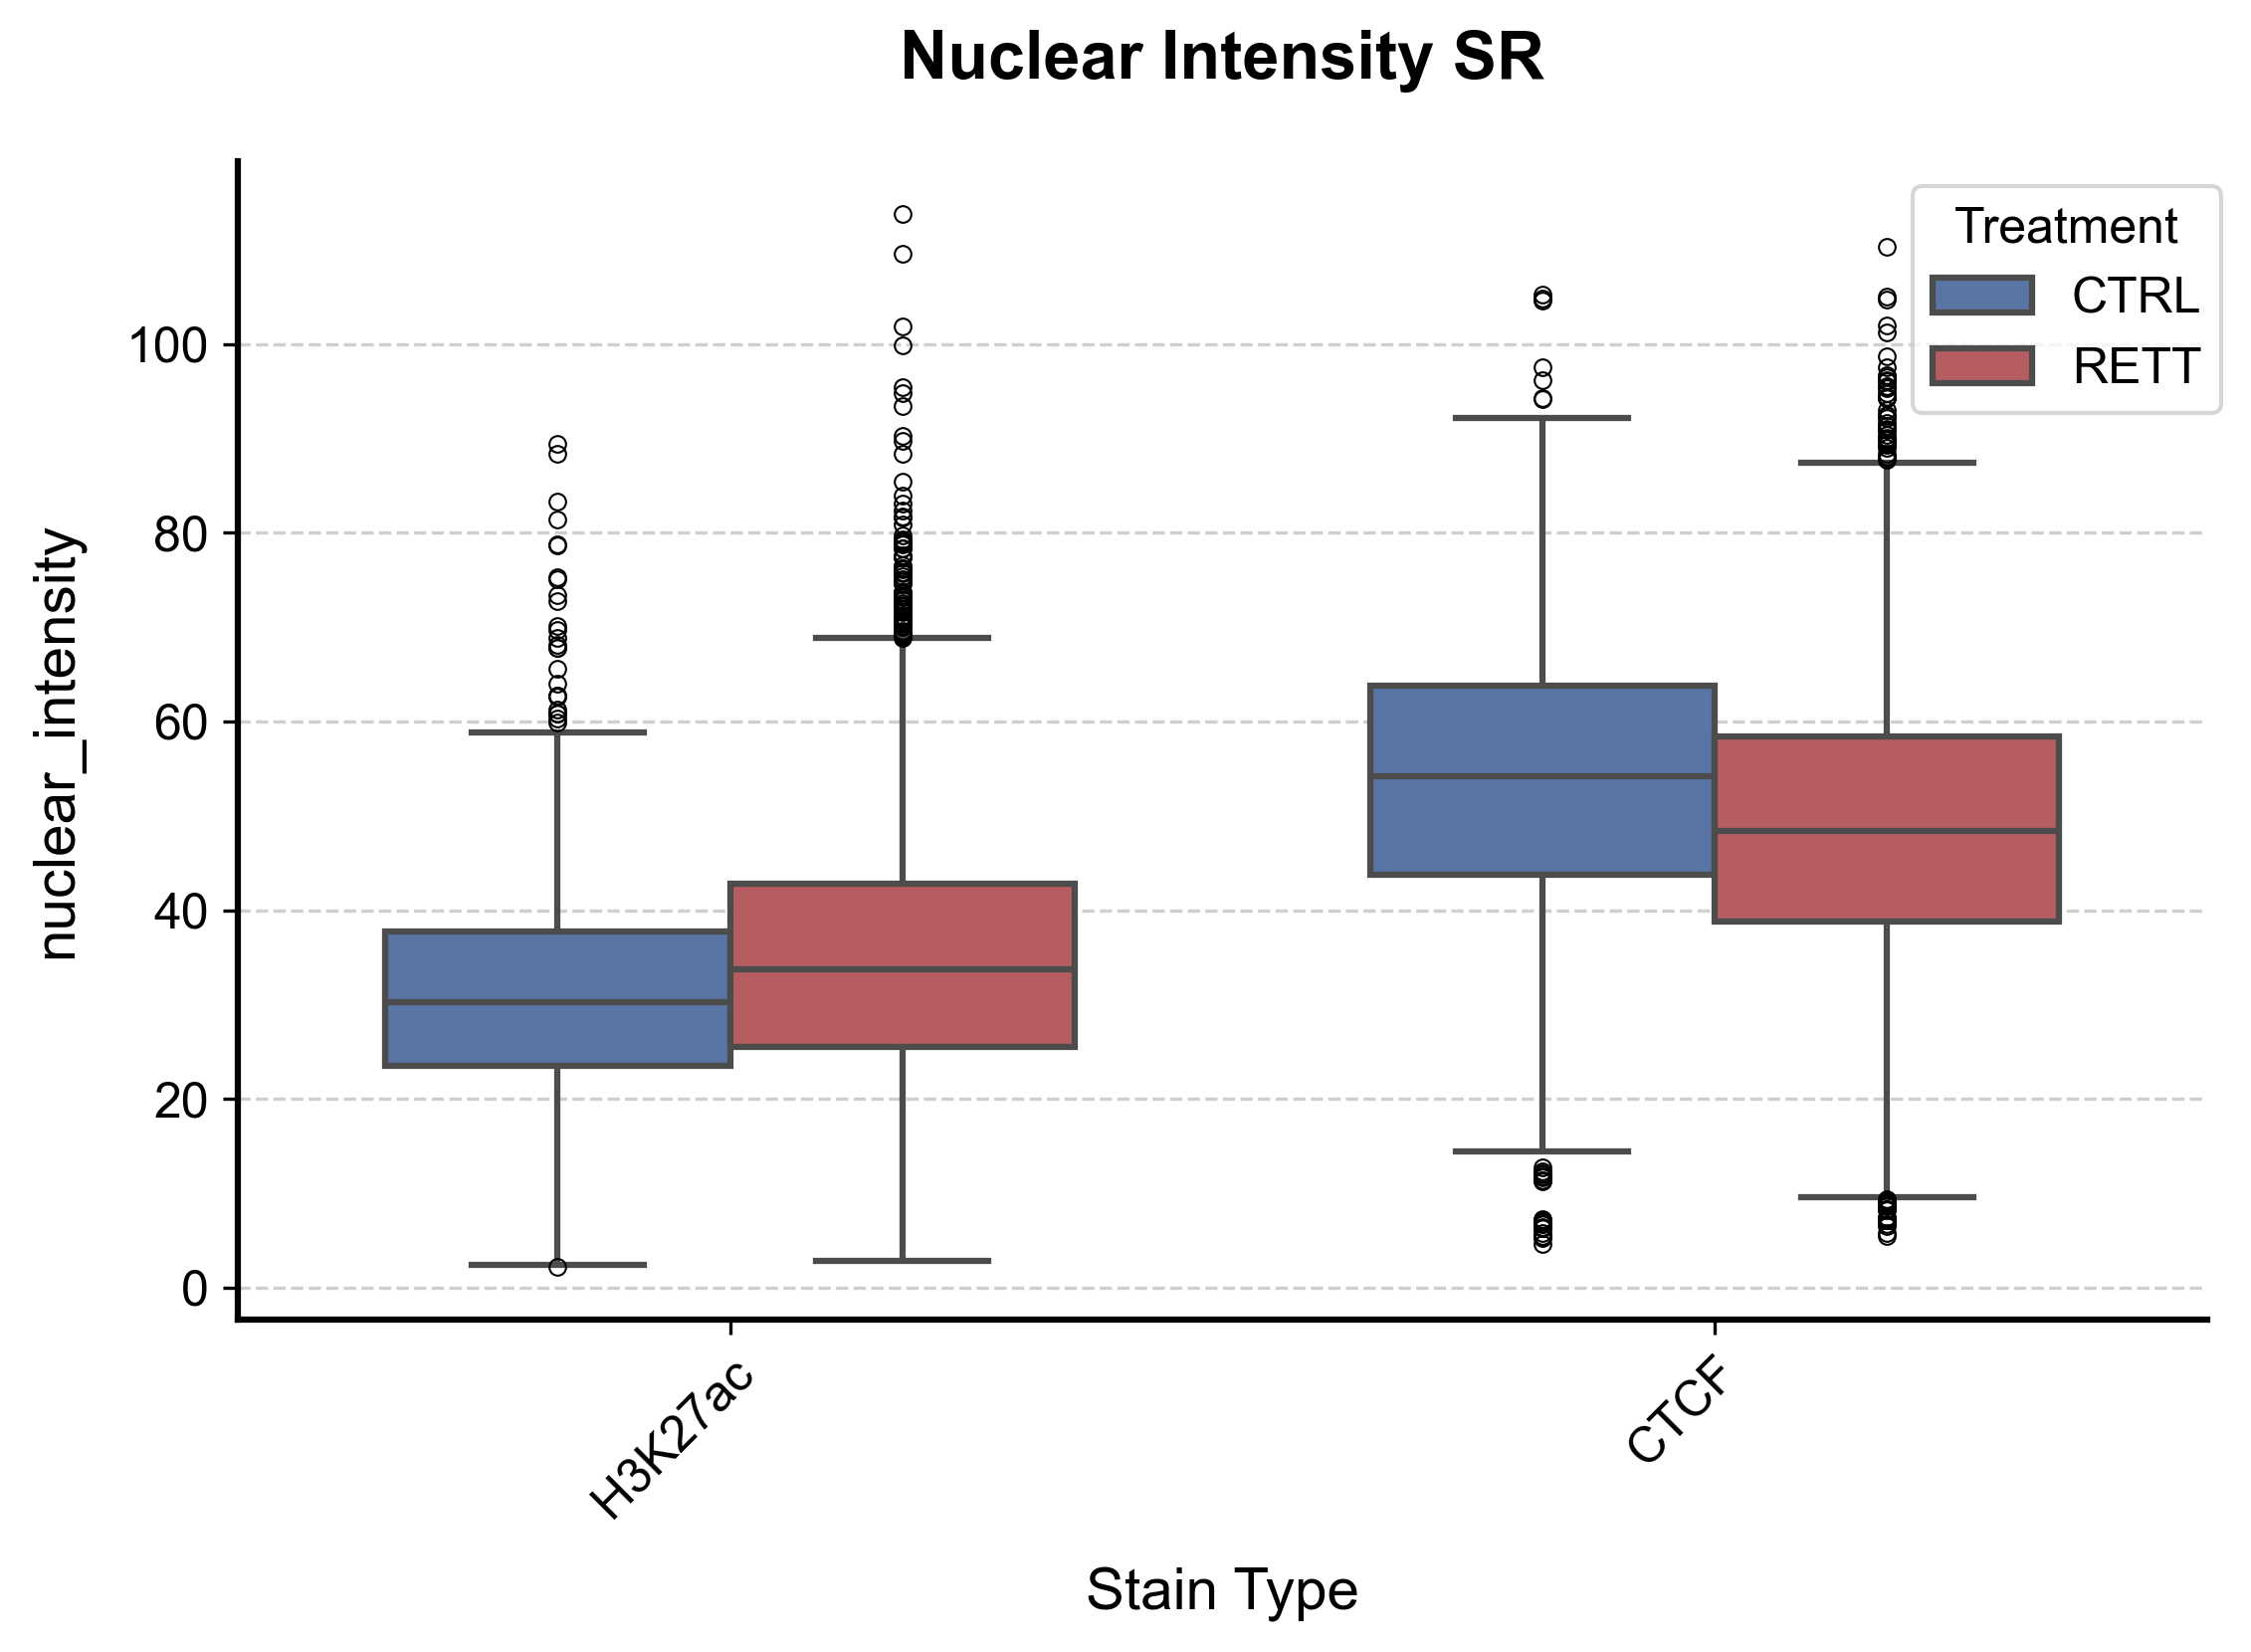

In [7]:
savepath = f"{homepath}/results_RTT/Biomarker/results_figures"
savetitle={'chromatin_num':  'Puncta Number',
       'chromatin_area': 'Puncta Area',
       'chromatin_shape':'Puncta Shape irrigularity',
       'chromatin_intensity':'Puncta Intensity',
       'chromatin_distribution_part5': 'Puncta Periphery Enrichment',
       'nuclear_intensity': 'Nuclear Intensity'
      }

for feature in ['chromatin_num', 'chromatin_area', 'chromatin_shape', 'chromatin_intensity', 'chromatin_distribution_part5', 'nuclear_intensity']:
    print(f"\n=== Feature: {feature} ===")
    print(calculate_ttest_pvalues(data_all, group_col='Stain_Type', condition_col='State', value_col=feature))
    validata_boxplot(data_all, feature, savepath, rett="RETT", data=data)

H3K27ac
     Part  t-statistic       p-value
0  Part 1     6.217573  5.697547e-10
1  Part 2    10.483216  2.473939e-25
2  Part 3    15.414136  5.935748e-52
3  Part 4    16.482941  6.408108e-59
4  Part 5     6.632404  3.824086e-11


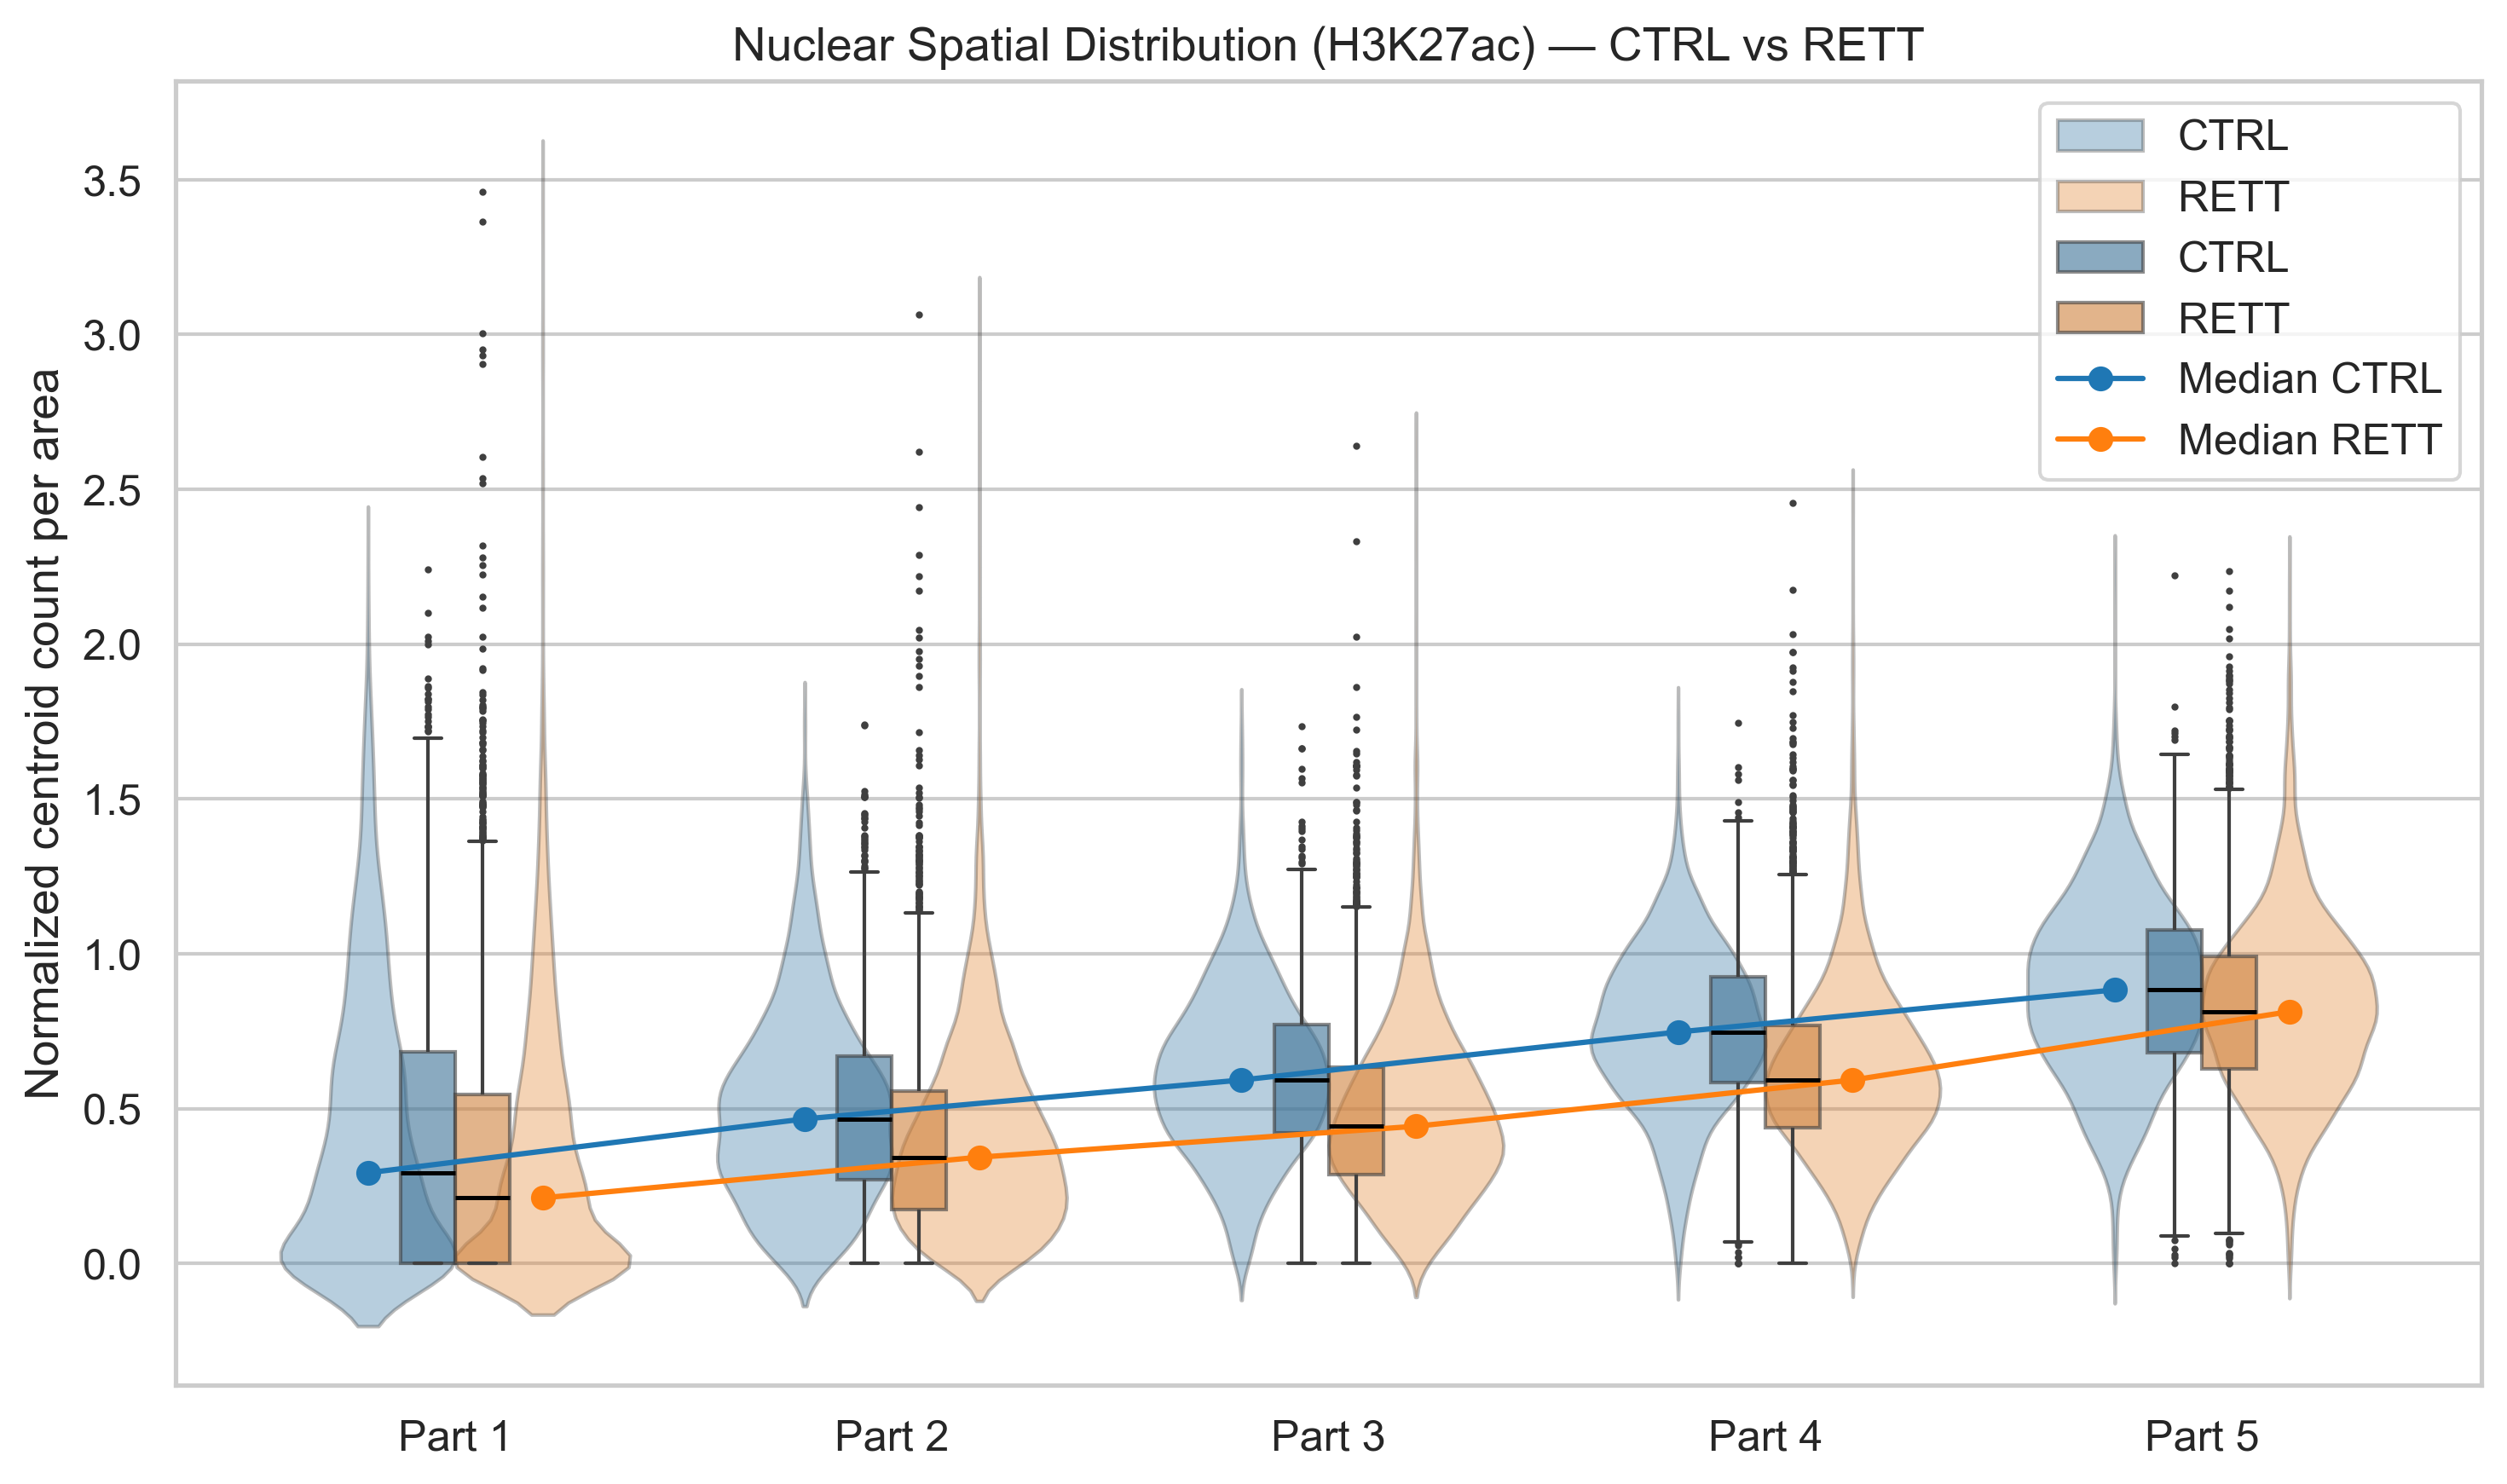

CTCF
     Part  t-statistic        p-value
0  Part 1    -4.997829   6.084506e-07
1  Part 2    -3.891085   1.015437e-04
2  Part 3     4.317591   1.613924e-05
3  Part 4    19.259204   2.658383e-79
4  Part 5    27.587195  1.601293e-152


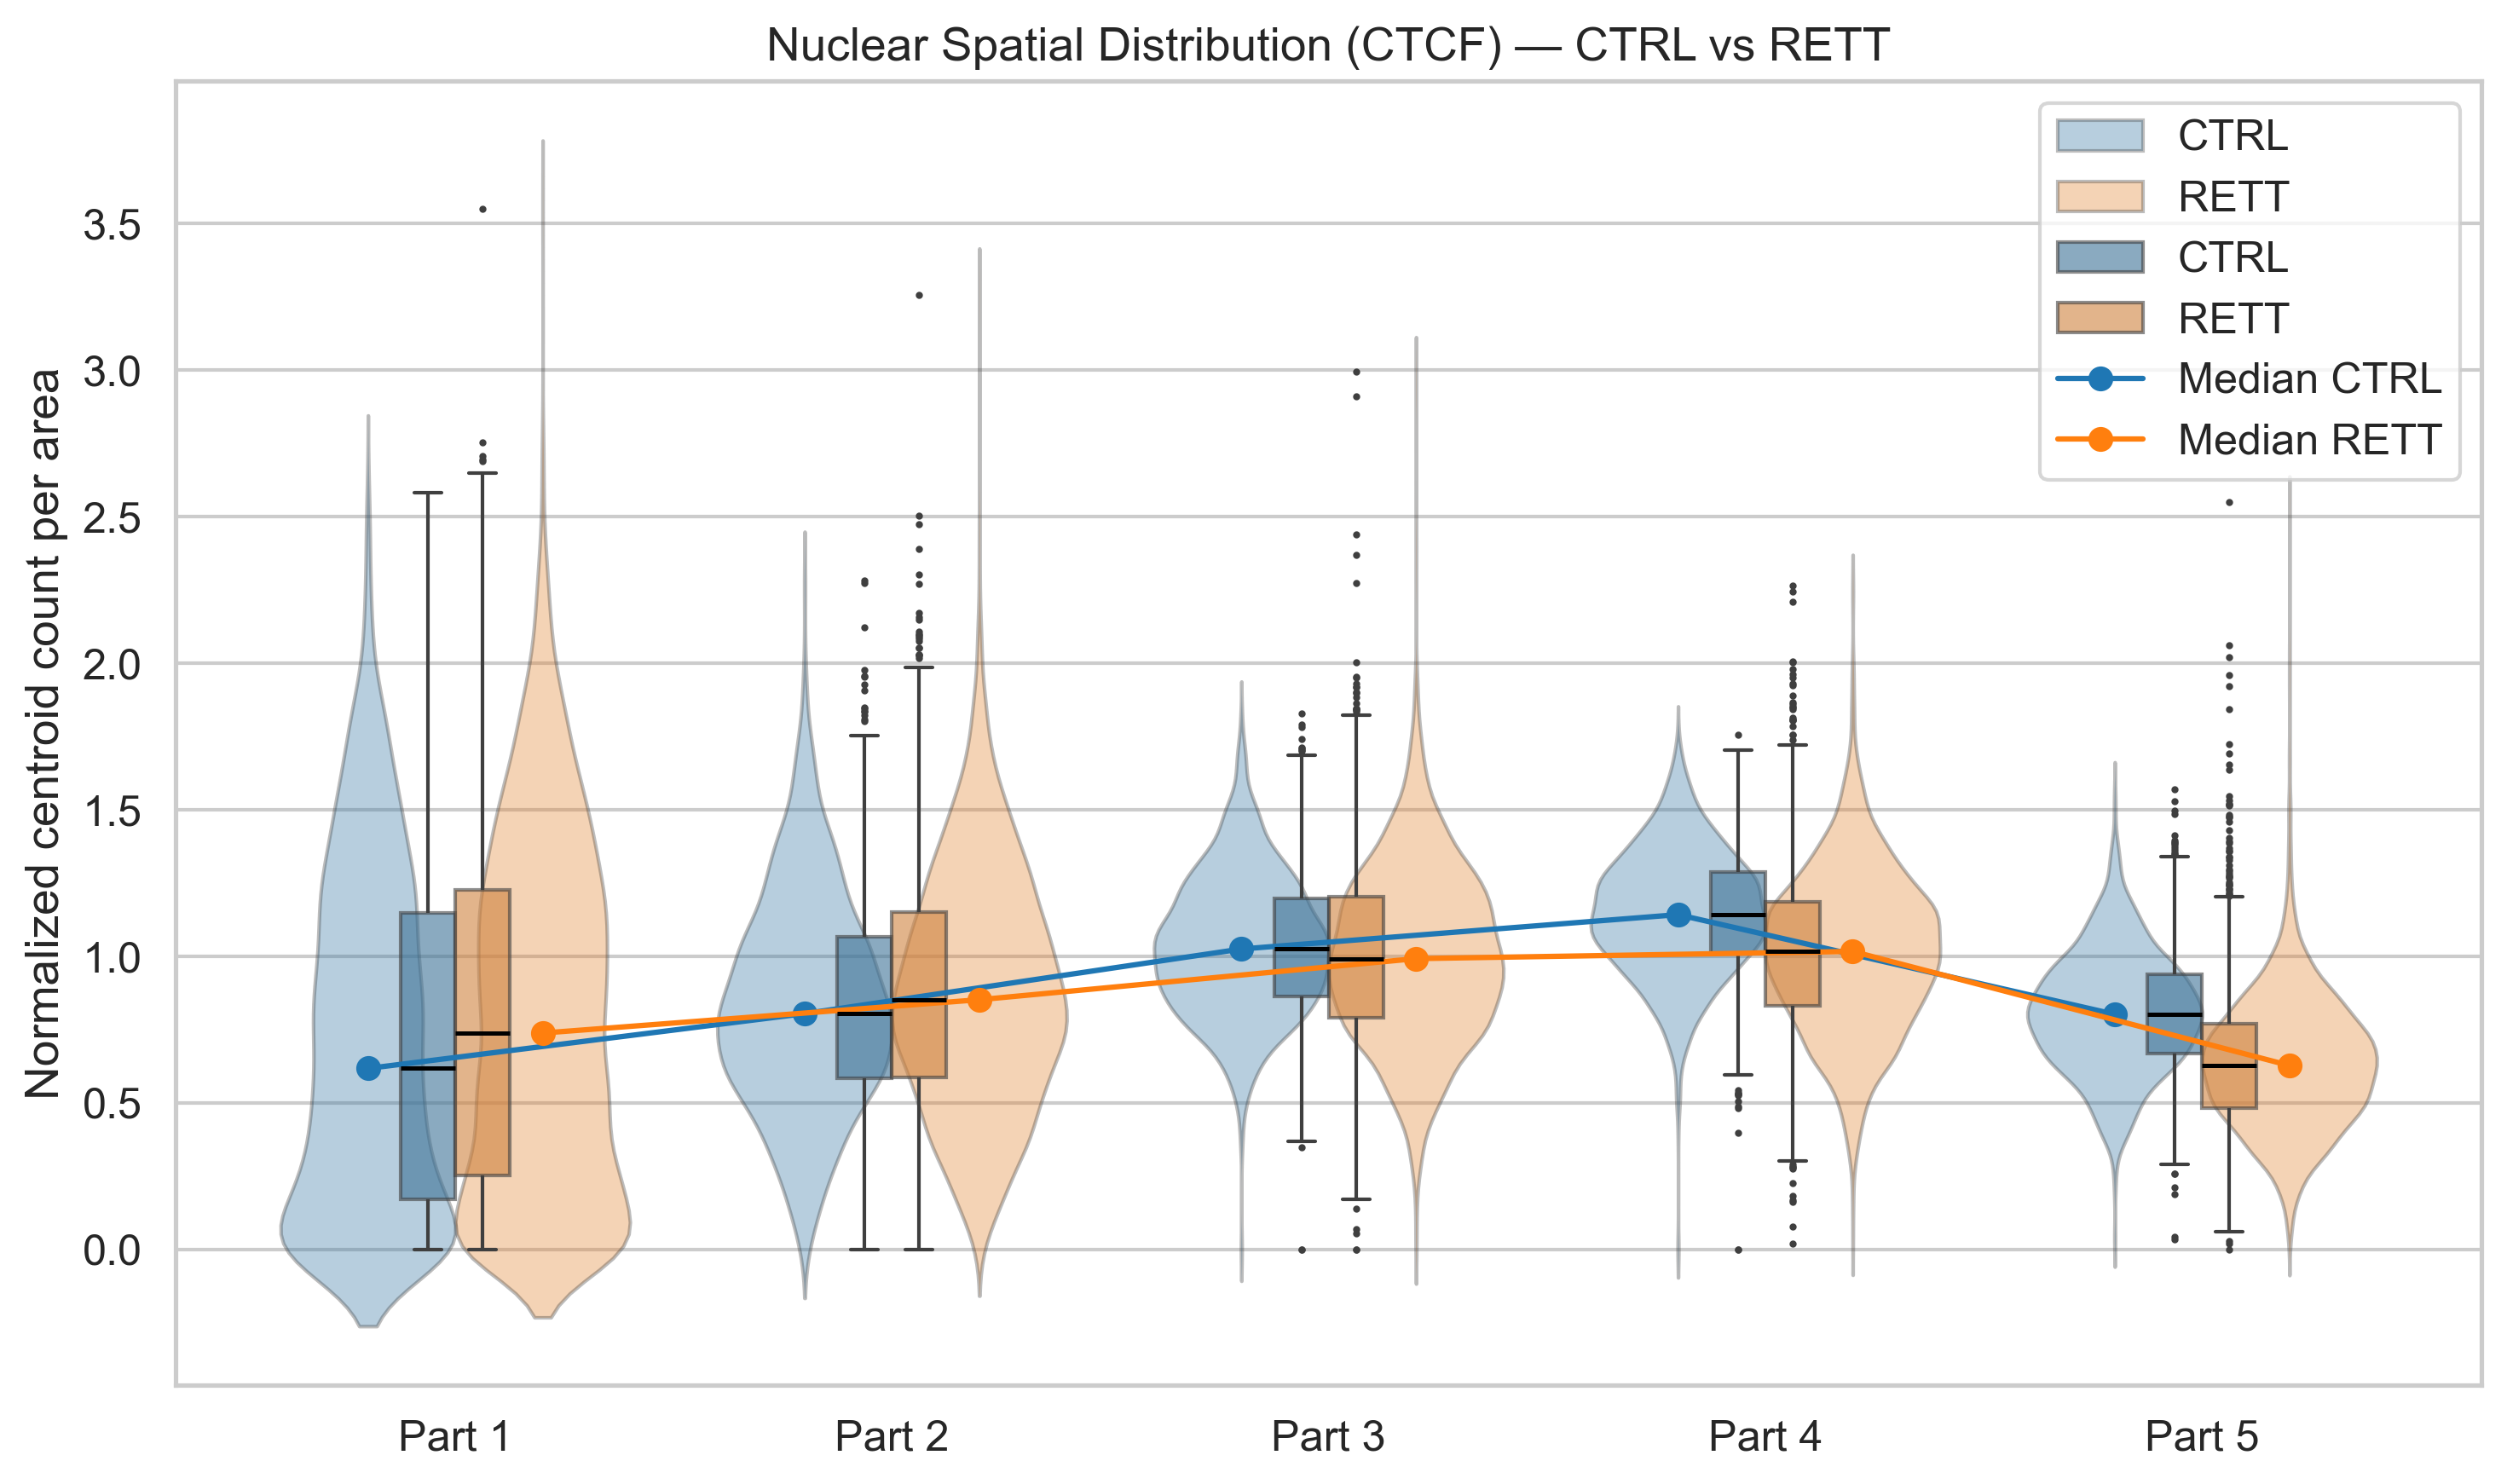

In [58]:
print("H3K27ac")
print(calculate_chromatin_distribution_pvalues(data_all, stain_type="H3K27ac"))
chromatin_distribution_plot(data_all, "H3K27ac", savepath)

print("CTCF")
print(calculate_chromatin_distribution_pvalues(data_all, stain_type="CTCF"))
chromatin_distribution_plot(data_all, "CTCF", savepath)

# BoxPlot for VPA

In [8]:
# 创建一个空的 DataFrame 用于存放所有数据
data_all = pd.DataFrame()
homepath = "/Users/Alpaca/Desktop/disease_epigenome"

for stain_type in ["H3K27ac", "CTCF"]:
    loadpath = f"{homepath}/results_VPA/Biomarker/new_results"
    loadpath_VPA = f"{loadpath}/VPA_{stain_type}_basic.csv"
    loadpath_CTRL = f"{loadpath}/CTRL_{stain_type}_basic.csv"
    
    df_combined, df_VPA, df_CTRL = loadcsv(loadpath_VPA, loadpath_CTRL, rett="VPA")
    
    df_combined['Stain_Type'] = f"{stain_type}"
    
    data_all = pd.concat([data_all, df_combined])
    
data_all["chromatin_compactness"] = 1 / data_all["chromatin_area"]
data_all["chromatin_integrated_intensity"] = data_all["chromatin_num"] * data_all["chromatin_intensity"]
data_all["chromatin_density"] = data_all["chromatin_num"] / data_all["nuclear_area"]
data_all.head(2)

,chromatin_num,chromatin_area,chromatin_intensity,chromatin_shape,nuclear_area,nuclear_intensity,chromatin_distribution_part1,chromatin_distribution_part2,chromatin_distribution_part3,chromatin_distribution_part4,chromatin_distribution_part5,RCA-S,RCA-M,RCI-S,RCI-M,State,Stain_Type,chromatin_compactness,chromatin_integrated_intensity,chromatin_density
0,1,80.000000,163.699997,1.052944,47966.0,31.118917,0.000000,0.000000,0.026061,0.000000,0.000000,0.001668,0.001668,5.260466,5.260466,CTRL,H3K27ac,0.012500,163.699997,0.000021
1,131,34.465649,74.582892,1.499350,177832.0,31.759880,0.105426,0.164134,0.196640,0.200953,0.179595,0.025389,0.000194,307.632110,2.348337,CTRL,H3K27ac,0.029014,9770.358917,0.000737


In [62]:
features = data_all.columns.tolist()
features.remove('State')
features.remove('Stain_Type')
summarize_trend_and_pvalue(data_all, features, sick="VPA", control="CTRL")

,Description,CTCF,H3K27ac,CTCF_pvalue,H3K27ac_pvalue
0,Chromatin num,Increased,Increased,0.00000e+00,0.00000e+00
1,Chromatin area,Decreased,Decreased,0.00000e+00,2.04711e-201
2,Chromatin intensity,Increased,Increased,7.66496e-21,3.72436e-66
3,Chromatin shape,Increased,Increased,4.49255e-241,0.00000e+00
4,Nuclear area,Decreased,Decreased,1.48739e-11,7.40916e-12
5,Nuclear intensity,Increased,Increased,1.93154e-254,0.00000e+00
6,Chromatin distribution part1,Increased,Increased,0.00000e+00,3.87208e-242
7,Chromatin distribution part2,Increased,Increased,0.00000e+00,4.06399e-264
8,Chromatin distribution part3,Increased,Increased,0.00000e+00,6.18544e-275
9,Chromatin distribution part4,Increased,Increased,0.00000e+00,0.00000e+00



=== Feature: nuclear_intensity ===
     Group   Comparison  t-statistic        p-value
0  H3K27ac  CTRL vs VPA   -75.057245   0.000000e+00
1     CTCF  CTRL vs VPA   -35.184031  1.763537e-248


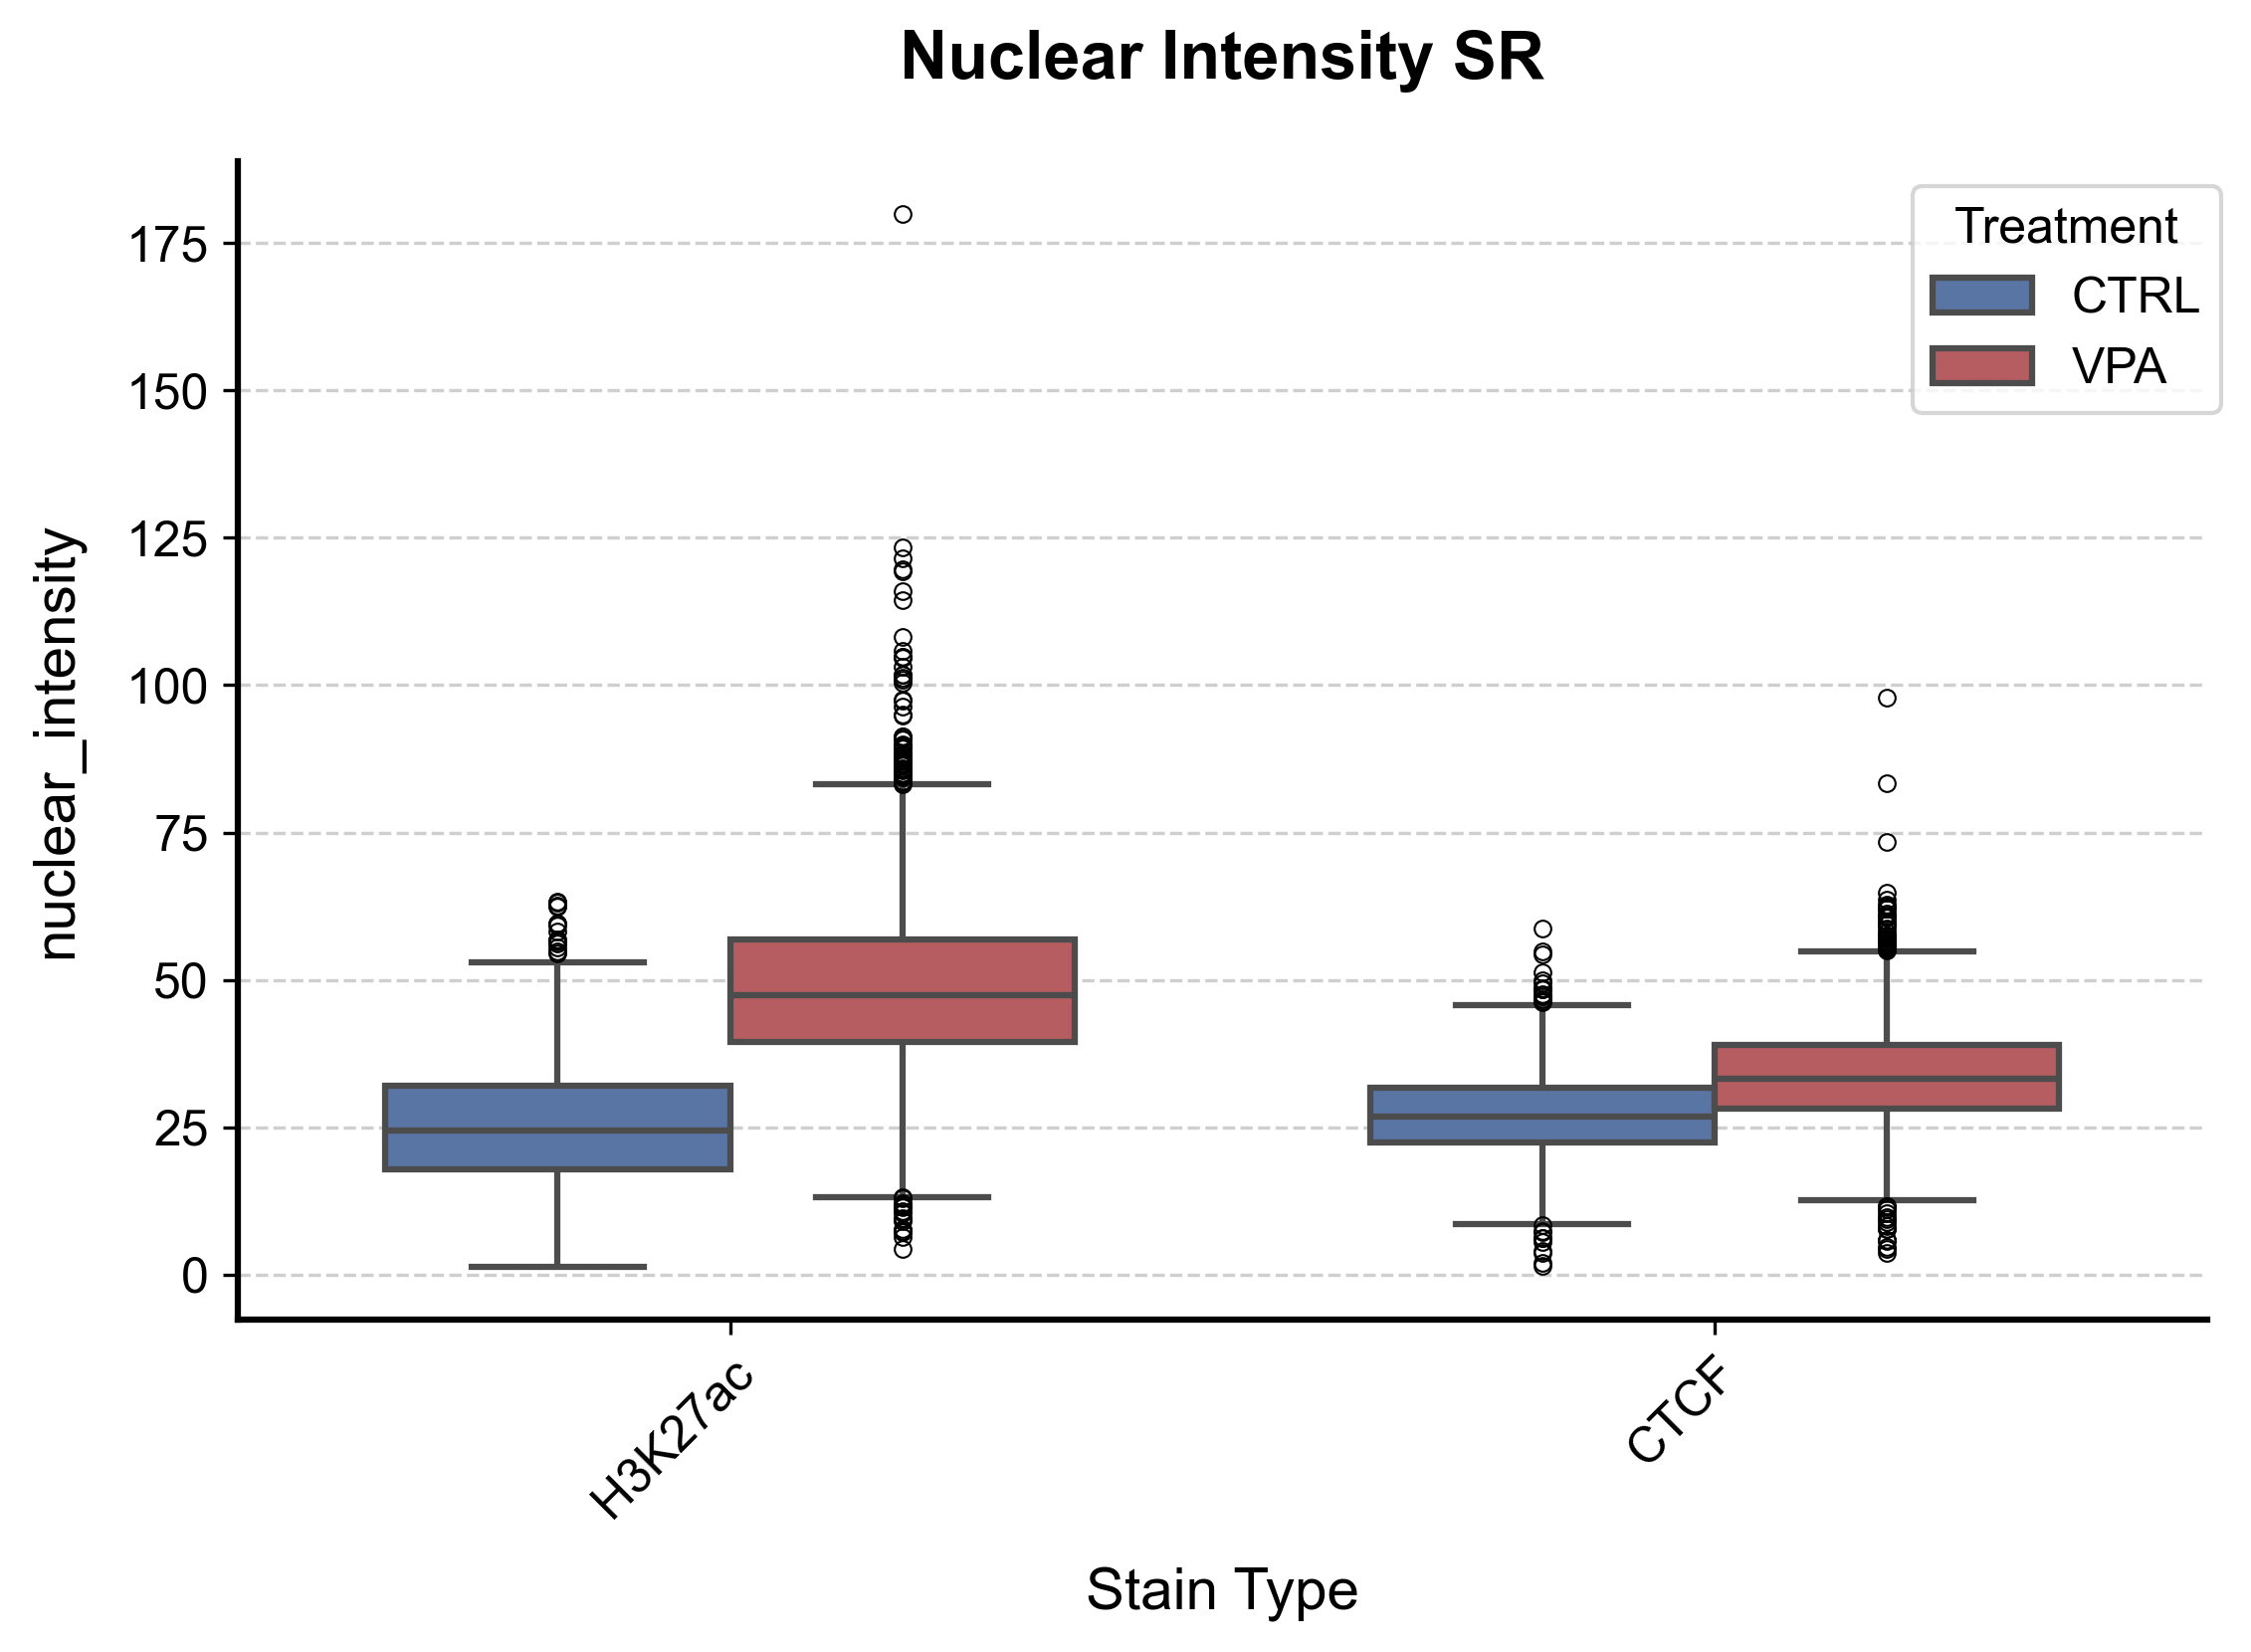

In [9]:
savepath = f"{homepath}/results_VPA/Biomarker/results_figures"

for feature in ['chromatin_num', 'chromatin_area', 'chromatin_shape', 'chromatin_intensity', 'chromatin_distribution_part5', 'nuclear_intensity']:
    print(f"\n=== Feature: {feature} ===")
    print(calculate_ttest_pvalues(data_all, group_col='Stain_Type', condition_col='State', value_col=feature))
    validata_boxplot(data_all, feature, savepath, rett="VPA")

H3K27ac
     Part  t-statistic        p-value
0  Part 1   -34.783059  3.872084e-242
1  Part 2   -36.492422  4.063993e-264
2  Part 3   -37.331032  6.185445e-275
3  Part 4   -40.226978   0.000000e+00
4  Part 5   -33.629424  1.916162e-228


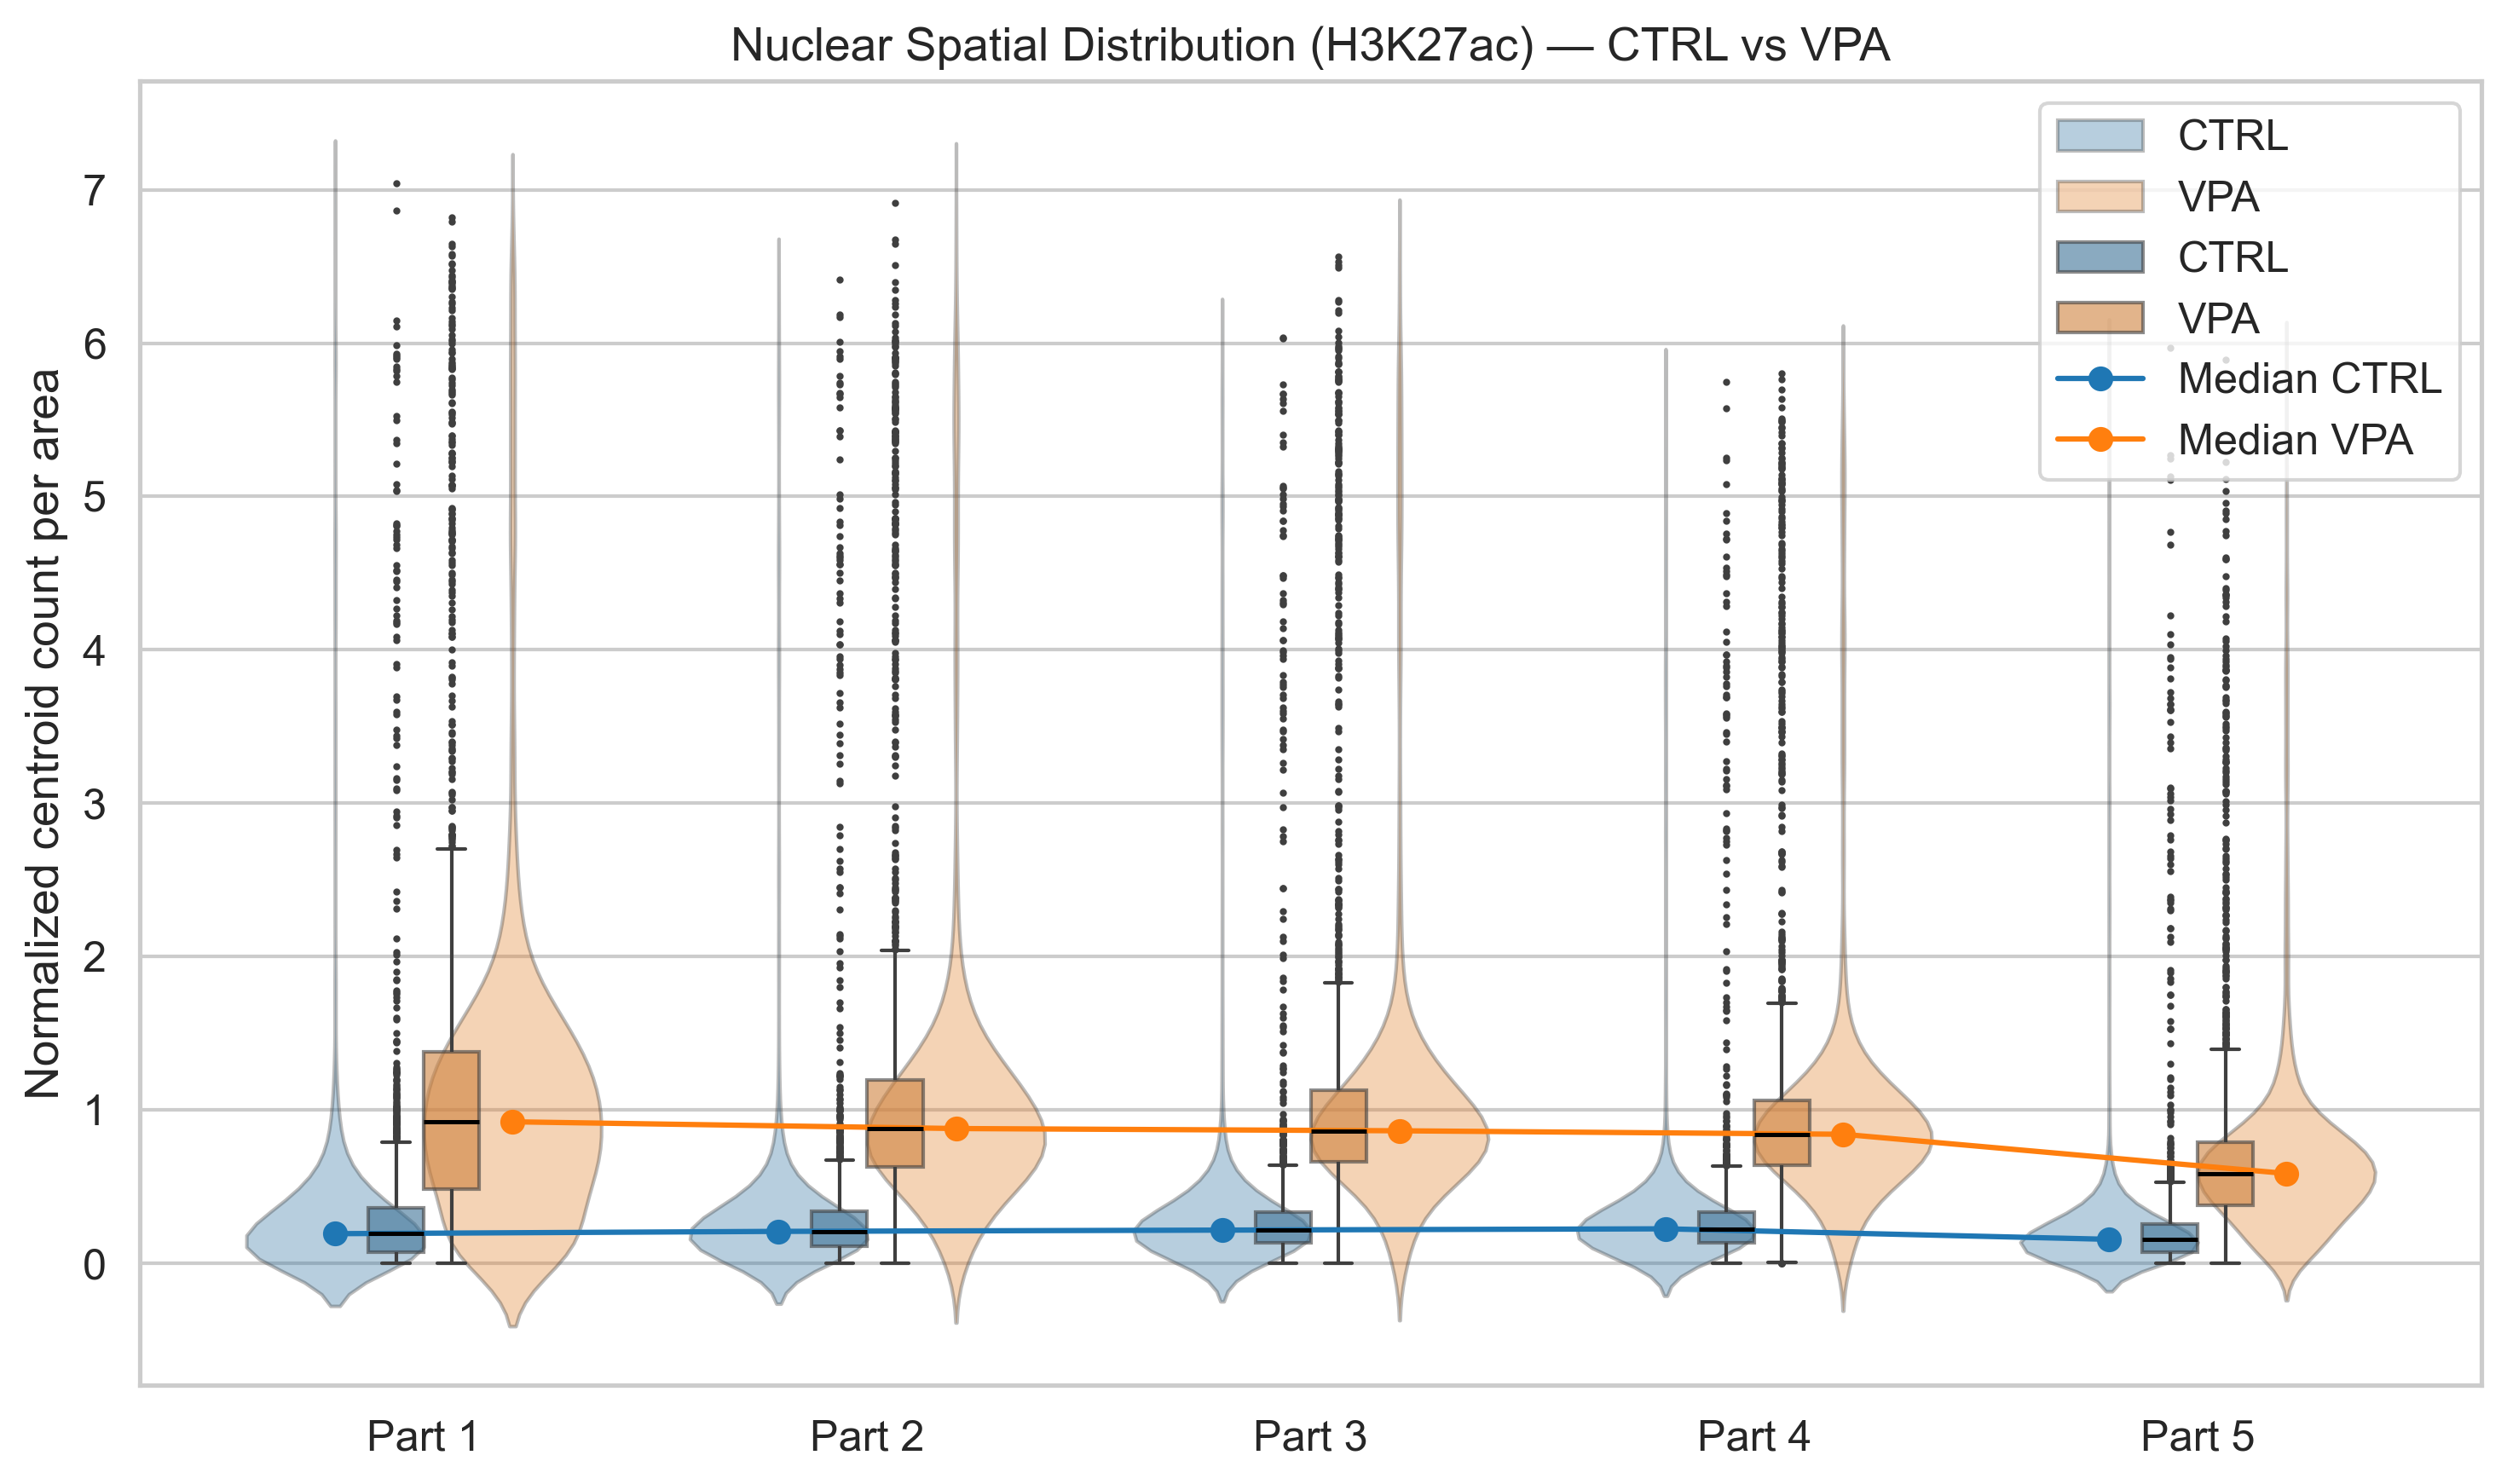

CTCF
     Part  t-statistic  p-value
0  Part 1   -47.608892      0.0
1  Part 2   -53.245400      0.0
2  Part 3   -54.898414      0.0
3  Part 4   -54.438791      0.0
4  Part 5   -47.666281      0.0


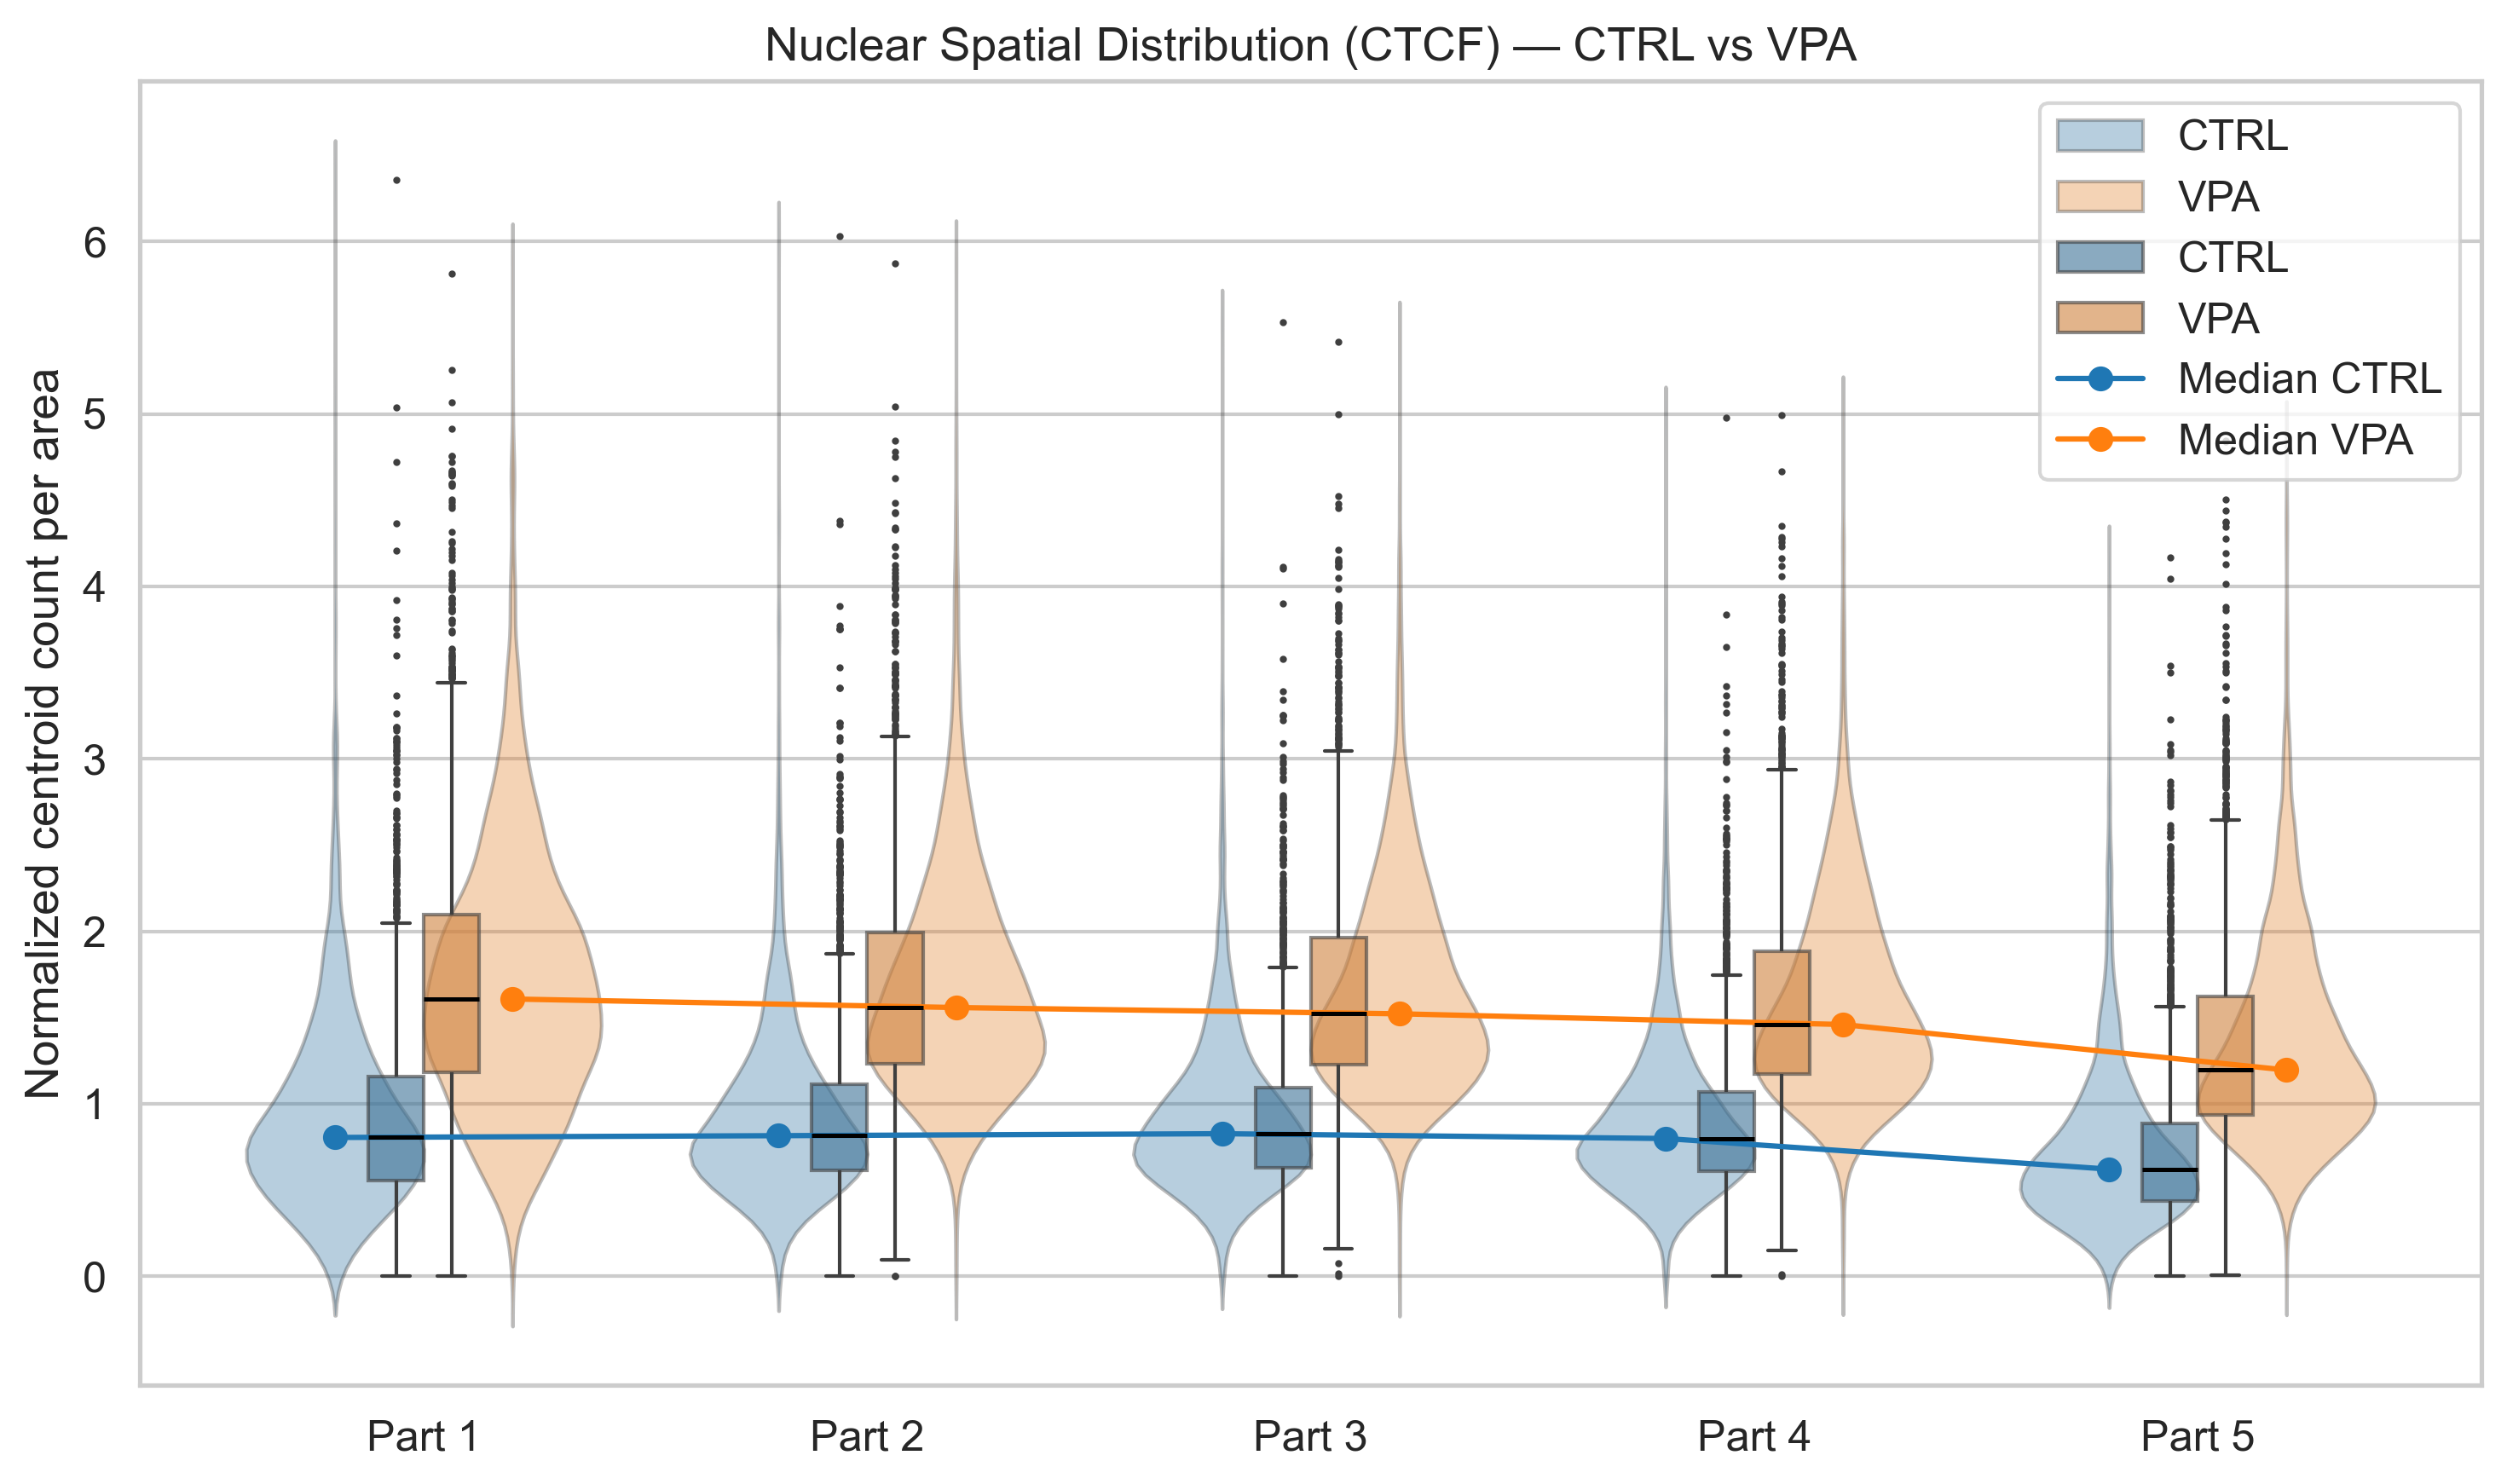

In [65]:
print("H3K27ac")
print(calculate_chromatin_distribution_pvalues(data_all, stain_type="H3K27ac", rett="VPA"))
chromatin_distribution_plot(data_all, "H3K27ac", savepath, rett="VPA")

print("CTCF")
print(calculate_chromatin_distribution_pvalues(data_all, stain_type="CTCF", rett="VPA"))
chromatin_distribution_plot(data_all, "CTCF", savepath, rett="VPA")

In [9]:
import numpy as np

original_resolution = 50  # nm/px
sigma = (11 - 1) / 6
effective_resolution = np.sqrt((sigma * original_resolution)**2 + original_resolution**2)

print(f"Effective resolution after Gaussian blur: {effective_resolution:.2f} nm/px")

Effective resolution after Gaussian blur: 97.18 nm/px


In [49]:
data_all = pd.DataFrame()
homepath = "/Users/Alpaca/Desktop/disease_epigenome"

for data in ["SR", "LR"]:
    for stain_type in ["H3K27ac", "CTCF"]:
        loadpath = f"{homepath}/results_RTT/Biomarker/new_results/results_{data}"
        loadpath_RETT = f"{loadpath}/RETT_HPS9999_{stain_type}_basic.csv"
        loadpath_CTRL = f"{loadpath}/CTRL_{stain_type}_basic.csv"

        df_combined, df_RETT, df_CTRL = loadcsv(loadpath_RETT, loadpath_CTRL, rett="RETT")
        df_combined['Stain_Type'] = f"{data}_{stain_type}"  # 关键：SR_H3K27ac 等
        data_all = pd.concat([data_all, df_combined])

# 计算新特征
data_all["chromatin_compactness"] = 1 / data_all["chromatin_area"]
data_all["chromatin_integrated_intensity"] = data_all["chromatin_num"] * data_all["chromatin_intensity"]
data_all["chromatin_density"] = data_all["chromatin_num"] / data_all["nuclear_area"]

In [60]:
def validata_boxplot_grouped(data_all, feature, savepath, rett="RETT", ylim=None):
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import pandas as pd

    matplotlib.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'font.size': 18,
        'axes.labelsize': 18,
        'axes.titlesize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'axes.linewidth': 1.5,
        'pdf.fonttype': 42,
        'figure.dpi': 300,
    })

    df = data_all.copy()
    df["Group"] = df["Stain_Type"]
    desired_order = ["SR_H3K27ac", "LR_H3K27ac", "SR_CTCF", "LR_CTCF"]

    palette_colors = {"CTRL": "#4C72B0", rett: "#C44E52"}

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        x="Group", y=feature,
        hue="State", data=df,
        order=desired_order, hue_order=["CTRL", "RETT"],
        palette=palette_colors,
        width=0.7, linewidth=1.5,
        flierprops=dict(marker='o', markersize=4,
                        markerfacecolor='none',
                        markeredgecolor='black',
                        markeredgewidth=0.5)
    )

    # === 计算每个箱子的平均值 ===
    means = (
        df.groupby(['Group','State'])[feature]
          .mean()
          .reindex(pd.MultiIndex.from_product([desired_order, ["CTRL", "RETT"]]))
    )
    print("\n--- 平均值 ---")
    print(means)   # 终端打印

    # 在图中添加平均值点和数字
    # 获取每个箱子的中心位置
    offsets = {'CTRL': -0.2, rett: 0.2}   # 与 dodge 宽度匹配
    for (grp, st), val in means.dropna().items():
        xpos = desired_order.index(grp) + (offsets[st])
        ax.scatter(xpos, val, color='black', marker='D', s=30, zorder=3)
        ax.text(xpos, val + 1, f"{val:.1f}",
                ha='center', va='bottom', fontsize=10, color='black')

    # 美化
    ax.spines[['right','top']].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.6, axis='y')
    ax.set_title(f"{savetitle[feature]} (SR + LR)", fontweight='bold', pad=20)
    ax.set_ylabel(feature, labelpad=10)
    ax.set_xlabel('Stain Type', labelpad=10)
    ax.legend(title='Treatment', title_fontsize=14, fontsize=12,
              loc='upper right', bbox_to_anchor=(1.02,1))
    plt.xticks(rotation=45, ha='right')

    if ylim is not None:
        plt.ylim(0, ylim)

    plt.tight_layout(pad=2.0)
    os.makedirs(savepath, exist_ok=True)
    plt.savefig(f"{savepath}/{feature}_SR_LR_grouped_mean.png",
                dpi=600, bbox_inches='tight', transparent=False)
    plt.show()
    plt.close()


=== Feature: chromatin_num ===
        Group    Comparison  t-statistic       p-value
0  SR_H3K27ac  CTRL vs RETT    12.013523  8.009077e-33
1     SR_CTCF  CTRL vs RETT     9.456211  4.669912e-21
2  LR_H3K27ac  CTRL vs RETT     1.148830  2.506778e-01
3     LR_CTCF  CTRL vs RETT    -1.555752  1.198265e-01

--- 平均值 ---
SR_H3K27ac  CTRL    108.355401
            RETT     94.080178
LR_H3K27ac  CTRL     61.147998
            RETT     60.430598
SR_CTCF     CTRL    141.492745
            RETT    128.379416
LR_CTCF     CTRL     88.535113
            RETT     89.891238
Name: chromatin_num, dtype: float64


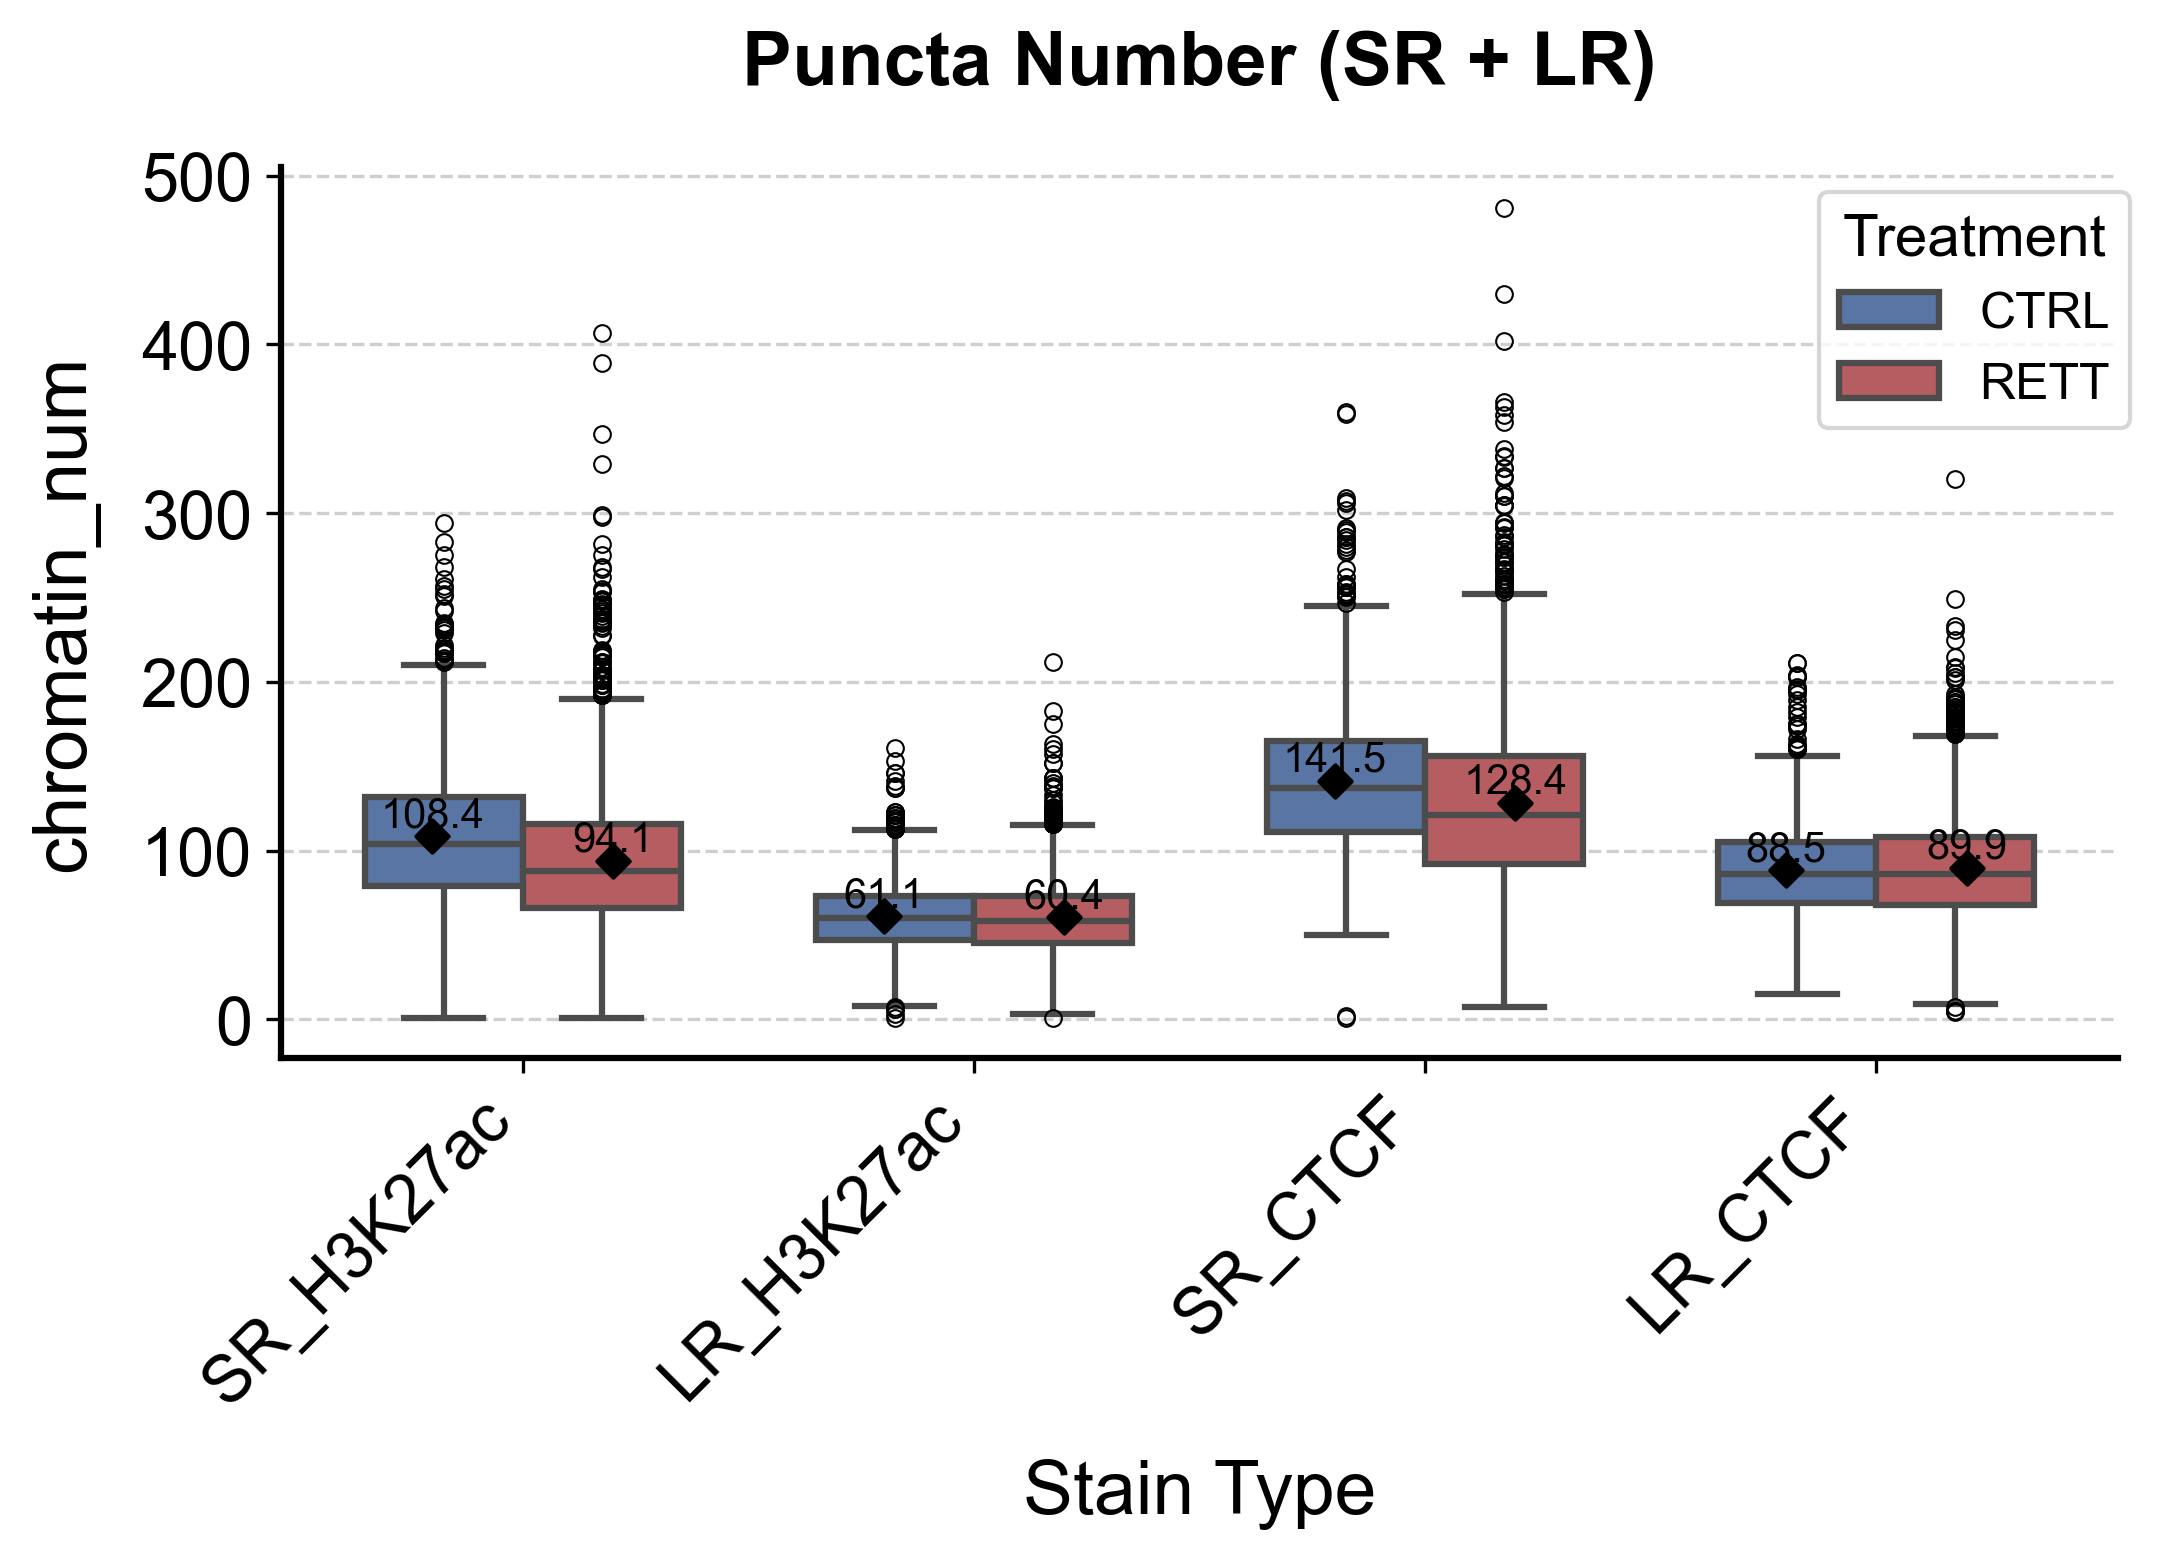


=== Feature: chromatin_area ===
        Group    Comparison  t-statistic       p-value
0  SR_H3K27ac  CTRL vs RETT     8.369401  7.328364e-17
1     SR_CTCF  CTRL vs RETT    20.829328  1.083763e-92
2  LR_H3K27ac  CTRL vs RETT    14.221382  4.490088e-45
3     LR_CTCF  CTRL vs RETT    16.122222  3.957910e-57

--- 平均值 ---
SR_H3K27ac  CTRL    27.317774
            RETT    25.002575
LR_H3K27ac  CTRL    86.403925
            RETT    79.595478
SR_CTCF     CTRL    16.847580
            RETT    14.222338
LR_CTCF     CTRL    74.681509
            RETT    68.954786
Name: chromatin_area, dtype: float64


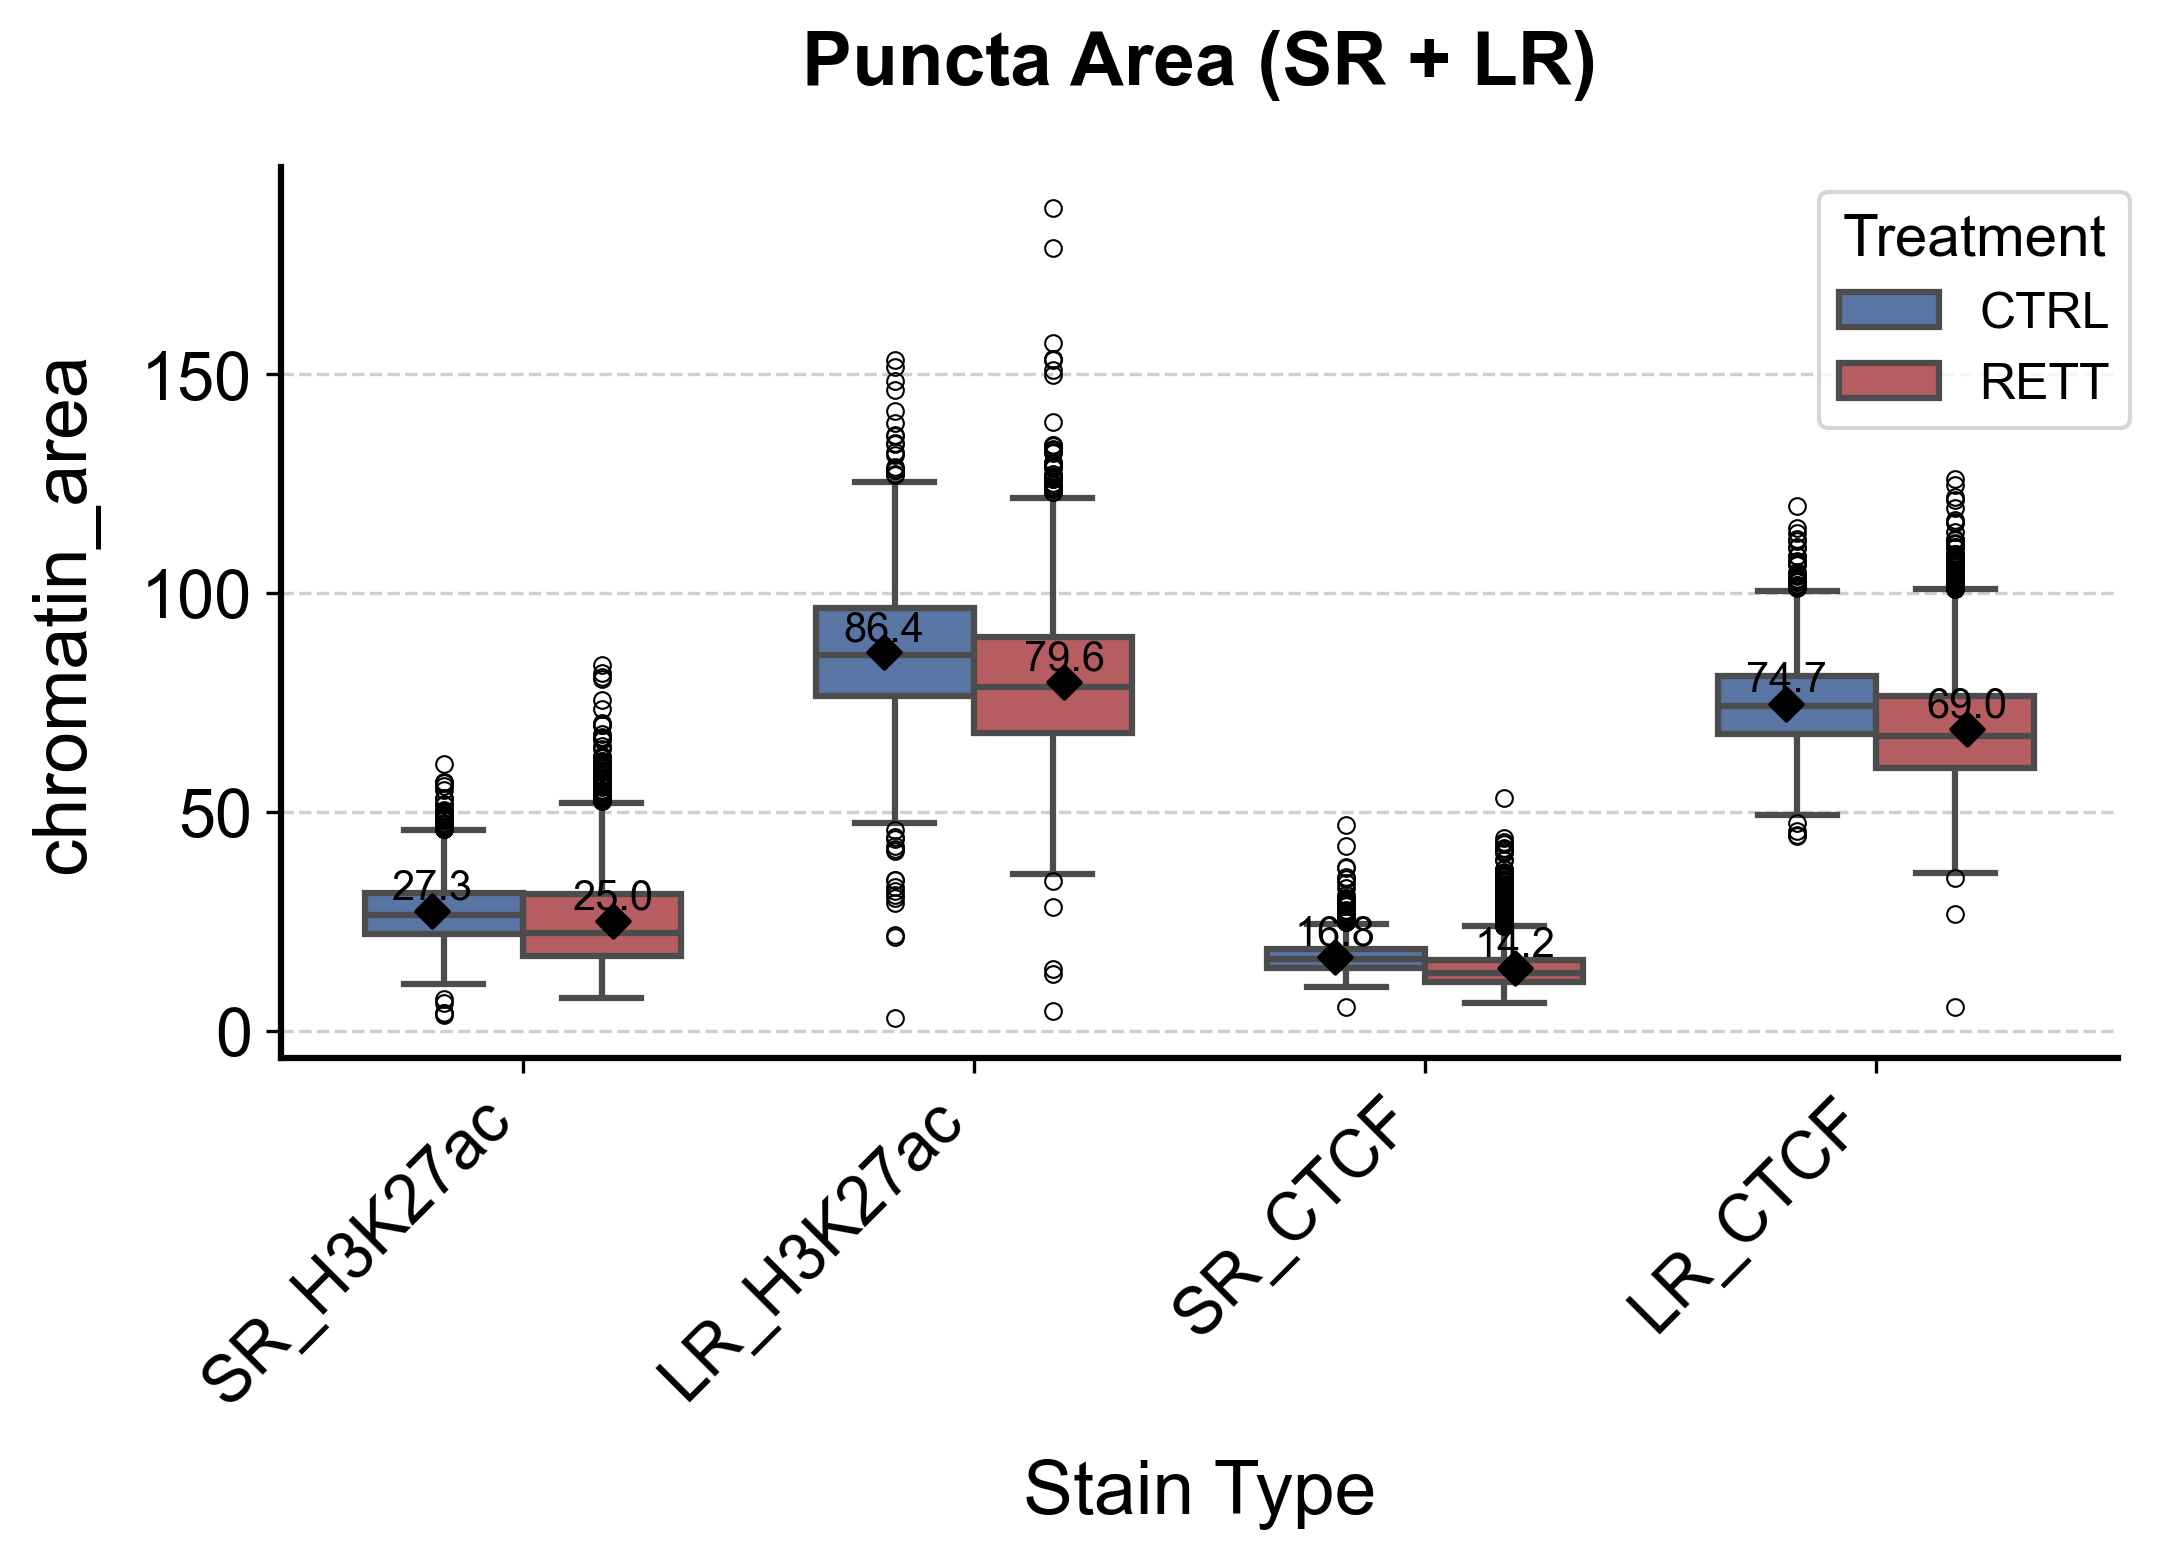


=== Feature: chromatin_shape ===
        Group    Comparison  t-statistic       p-value
0  SR_H3K27ac  CTRL vs RETT     8.463576  3.316172e-17
1     SR_CTCF  CTRL vs RETT    19.676318  2.967181e-83
2  LR_H3K27ac  CTRL vs RETT     4.497186  7.032379e-06
3     LR_CTCF  CTRL vs RETT    13.143991  7.396694e-39

--- 平均值 ---
SR_H3K27ac  CTRL    1.703487
            RETT    1.684581
LR_H3K27ac  CTRL    1.540398
            RETT    1.531437
SR_CTCF     CTRL    1.631790
            RETT    1.588668
LR_CTCF     CTRL    1.524552
            RETT    1.505790
Name: chromatin_shape, dtype: float64


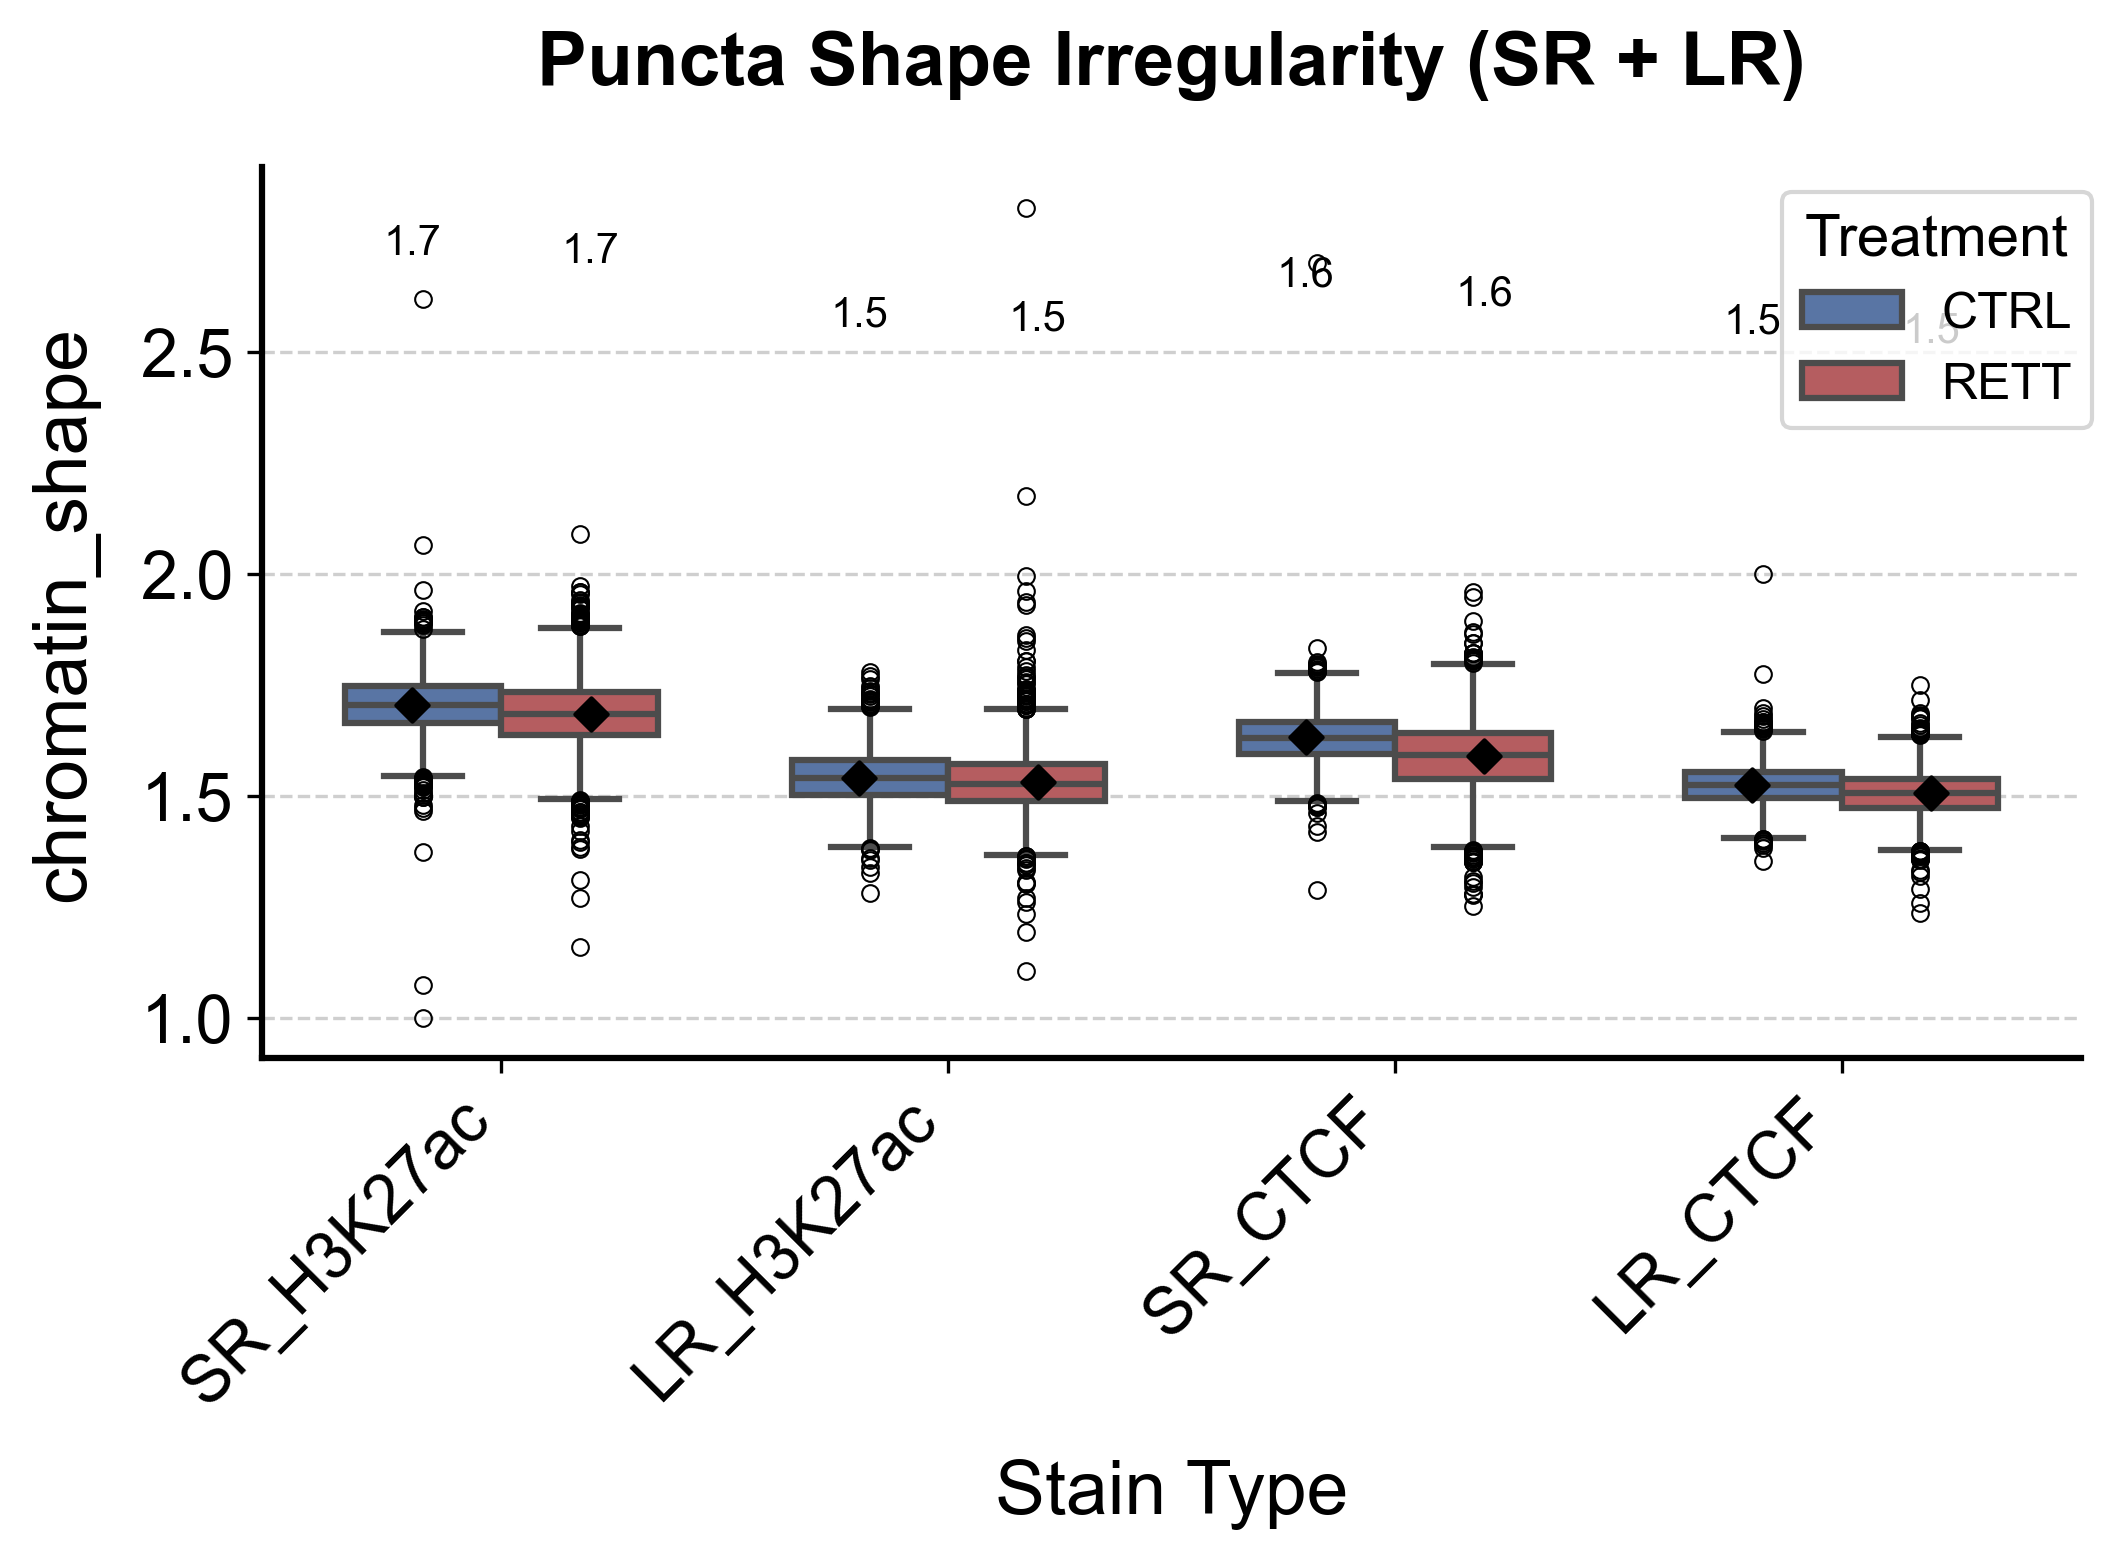


=== Feature: chromatin_intensity ===
        Group    Comparison  t-statistic       p-value
0  SR_H3K27ac  CTRL vs RETT   -15.934276  7.098963e-56
1     SR_CTCF  CTRL vs RETT     2.999791  2.714178e-03
2  LR_H3K27ac  CTRL vs RETT   -13.369074  4.051297e-40
3     LR_CTCF  CTRL vs RETT     8.569933  1.340463e-17

--- 平均值 ---
SR_H3K27ac  CTRL    43.935886
            RETT    53.555648
LR_H3K27ac  CTRL    37.568244
            RETT    44.257006
SR_CTCF     CTRL    82.549416
            RETT    80.406883
LR_CTCF     CTRL    65.787998
            RETT    60.988755
Name: chromatin_intensity, dtype: float64


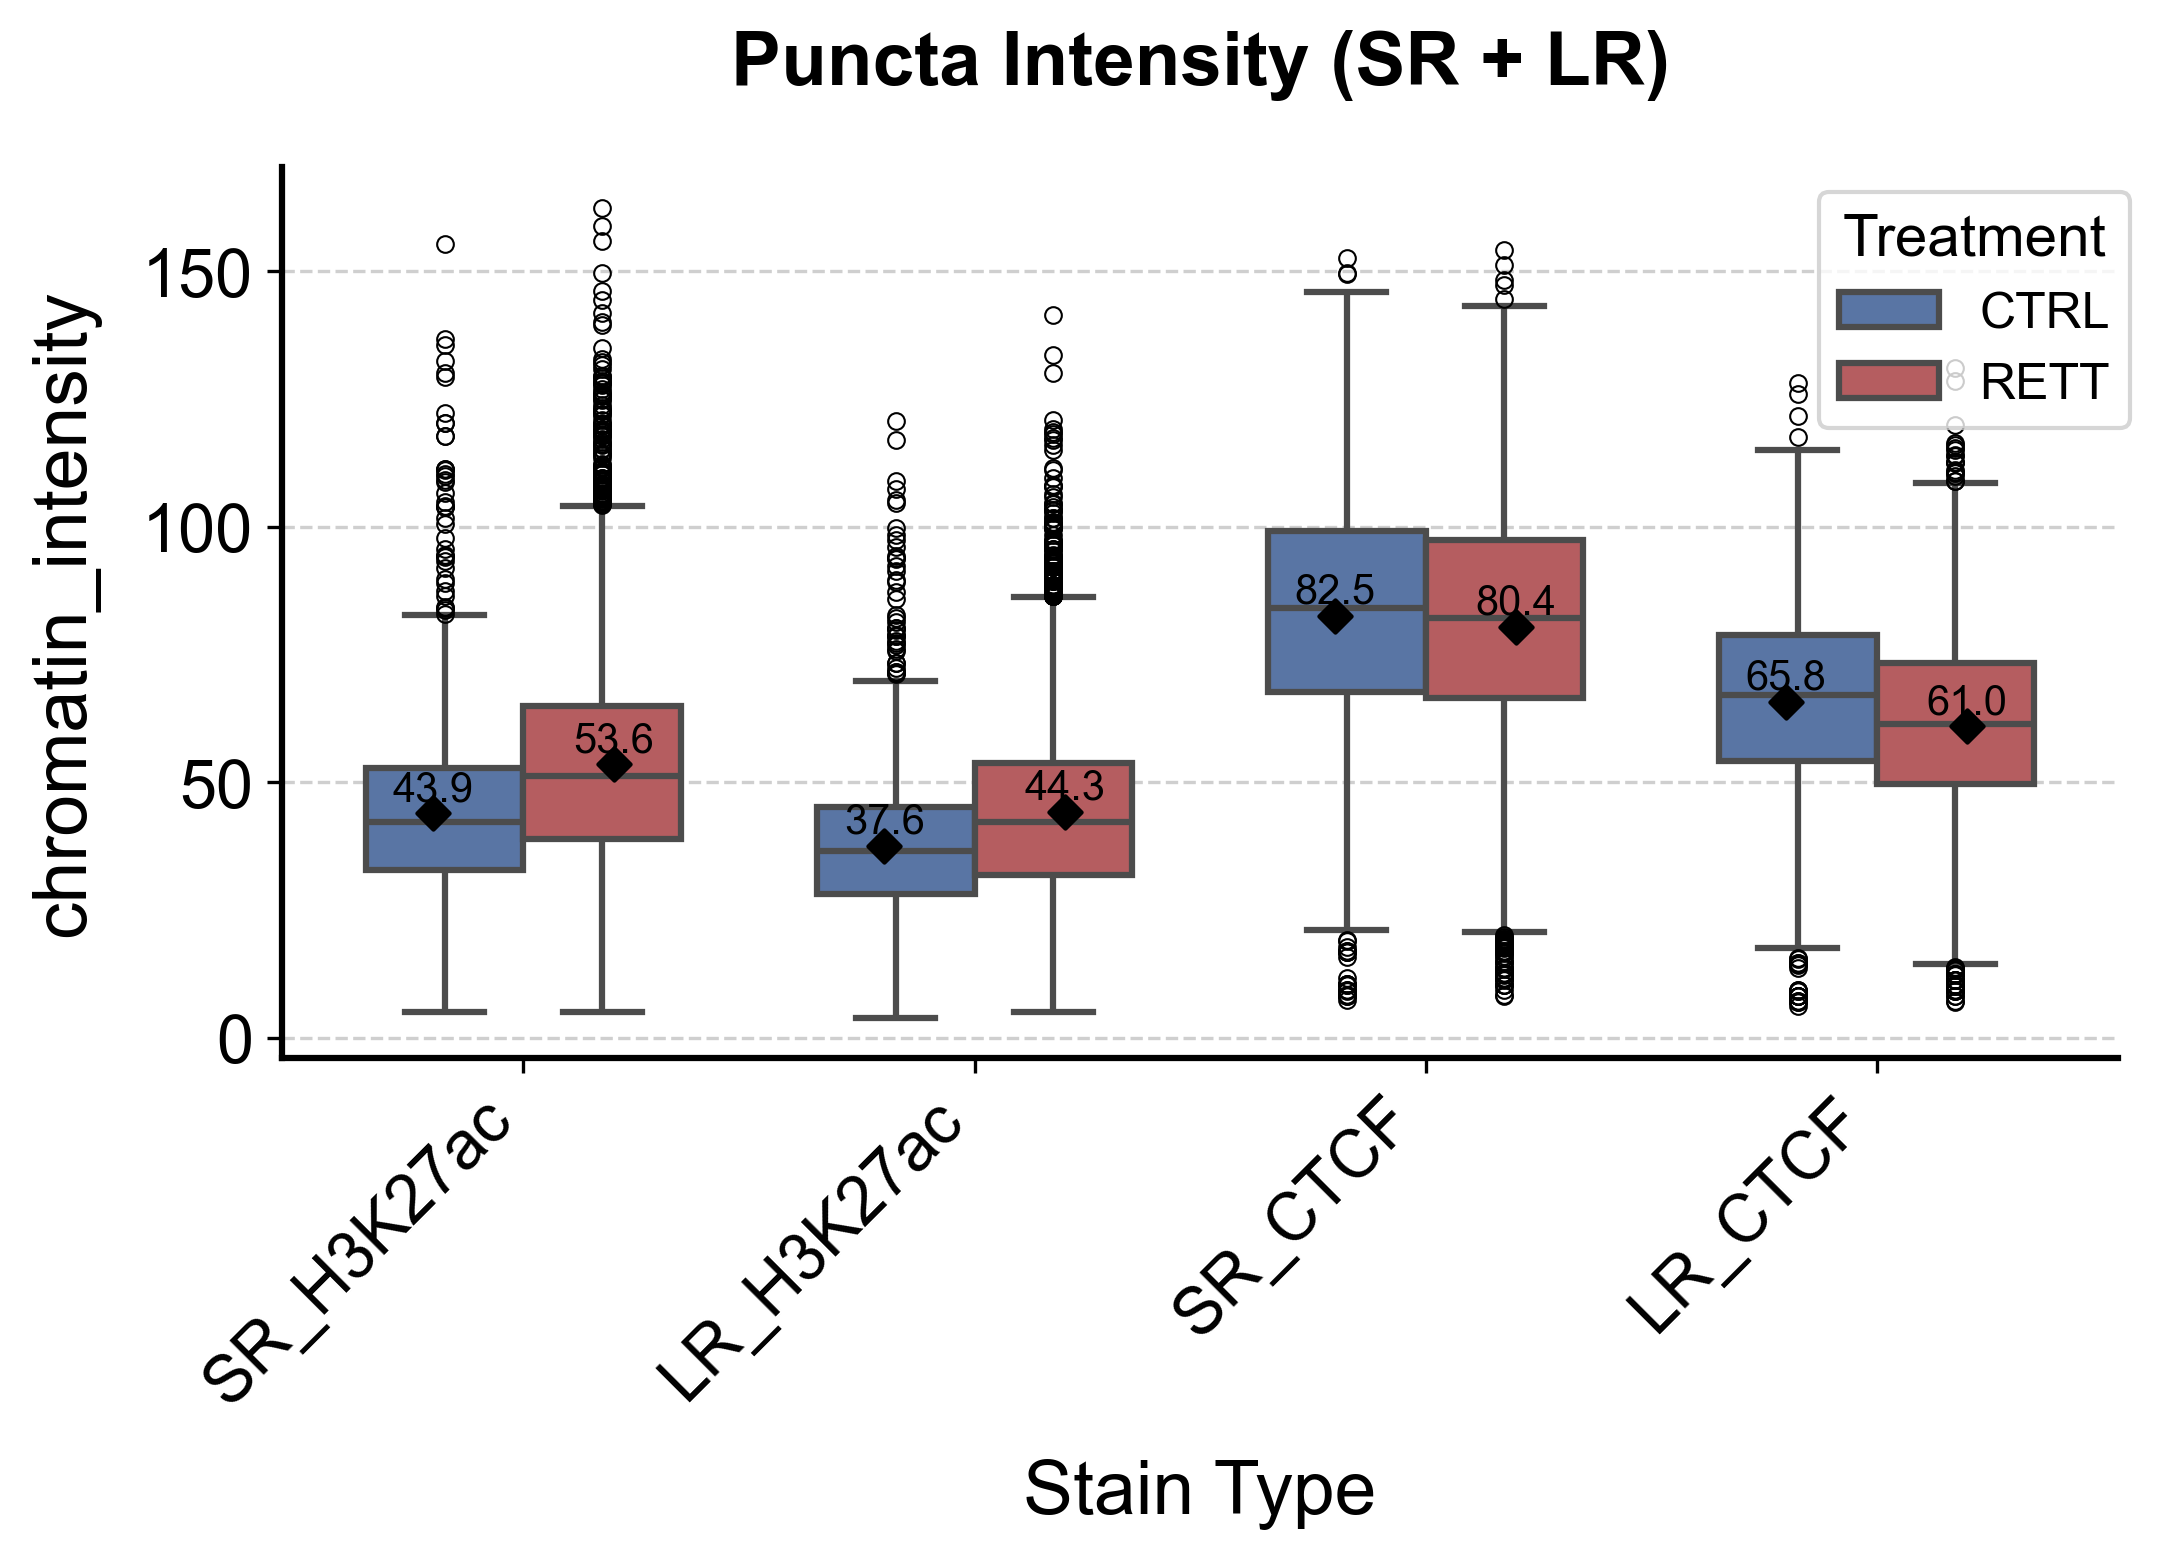


=== Feature: chromatin_distribution_part5 ===
        Group    Comparison  t-statistic        p-value
0  SR_H3K27ac  CTRL vs RETT     6.612262   4.156024e-11
1     SR_CTCF  CTRL vs RETT    26.676096  3.025145e-147
2  LR_H3K27ac  CTRL vs RETT    -6.285353   3.531857e-10
3     LR_CTCF  CTRL vs RETT    11.613429   8.271157e-31

--- 平均值 ---
SR_H3K27ac  CTRL    0.880428
            RETT    0.824771
LR_H3K27ac  CTRL    0.333627
            RETT    0.356786
SR_CTCF     CTRL    0.807083
            RETT    0.634535
LR_CTCF     CTRL    0.342482
            RETT    0.305816
Name: chromatin_distribution_part5, dtype: float64


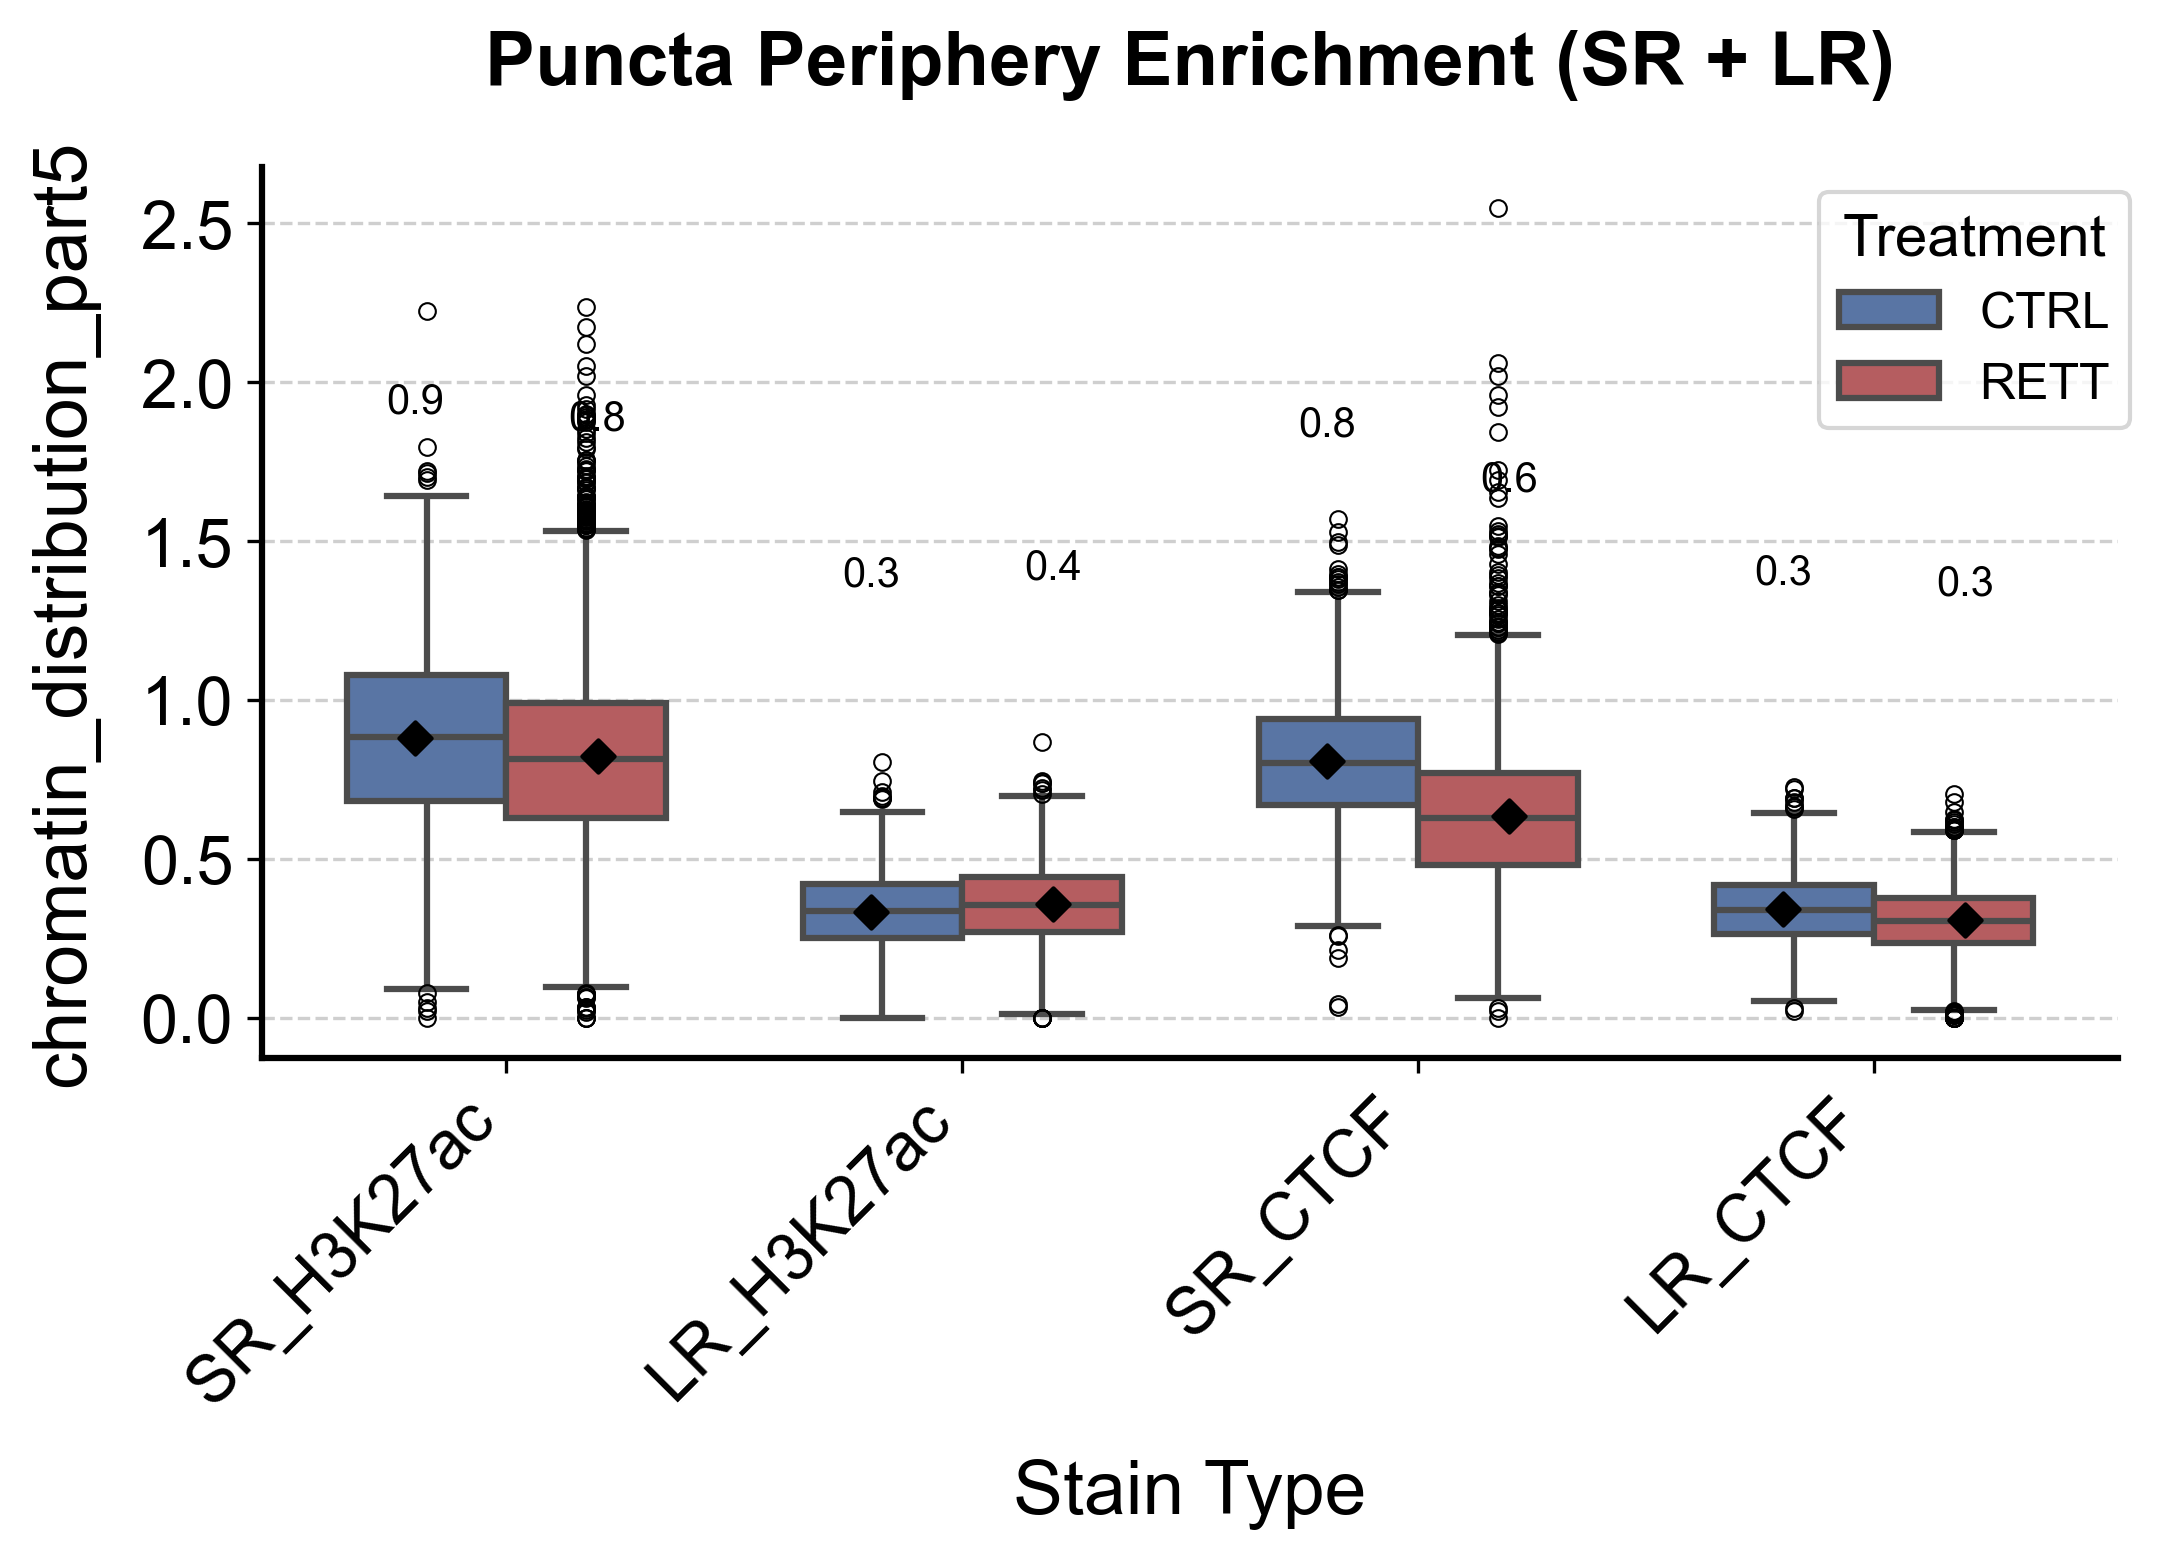


=== Feature: nuclear_intensity ===
        Group    Comparison  t-statistic       p-value
0  SR_H3K27ac  CTRL vs RETT   -10.655248  3.029090e-26
1     SR_CTCF  CTRL vs RETT    10.097008  9.316005e-24
2  LR_H3K27ac  CTRL vs RETT   -10.589191  6.055013e-26
3     LR_CTCF  CTRL vs RETT    10.038128  1.676089e-23

--- 平均值 ---
SR_H3K27ac  CTRL    30.922942
            RETT    35.036891
LR_H3K27ac  CTRL    28.581167
            RETT    32.326104
SR_CTCF     CTRL    53.372454
            RETT    48.652299
LR_CTCF     CTRL    49.134731
            RETT    44.845318
Name: nuclear_intensity, dtype: float64


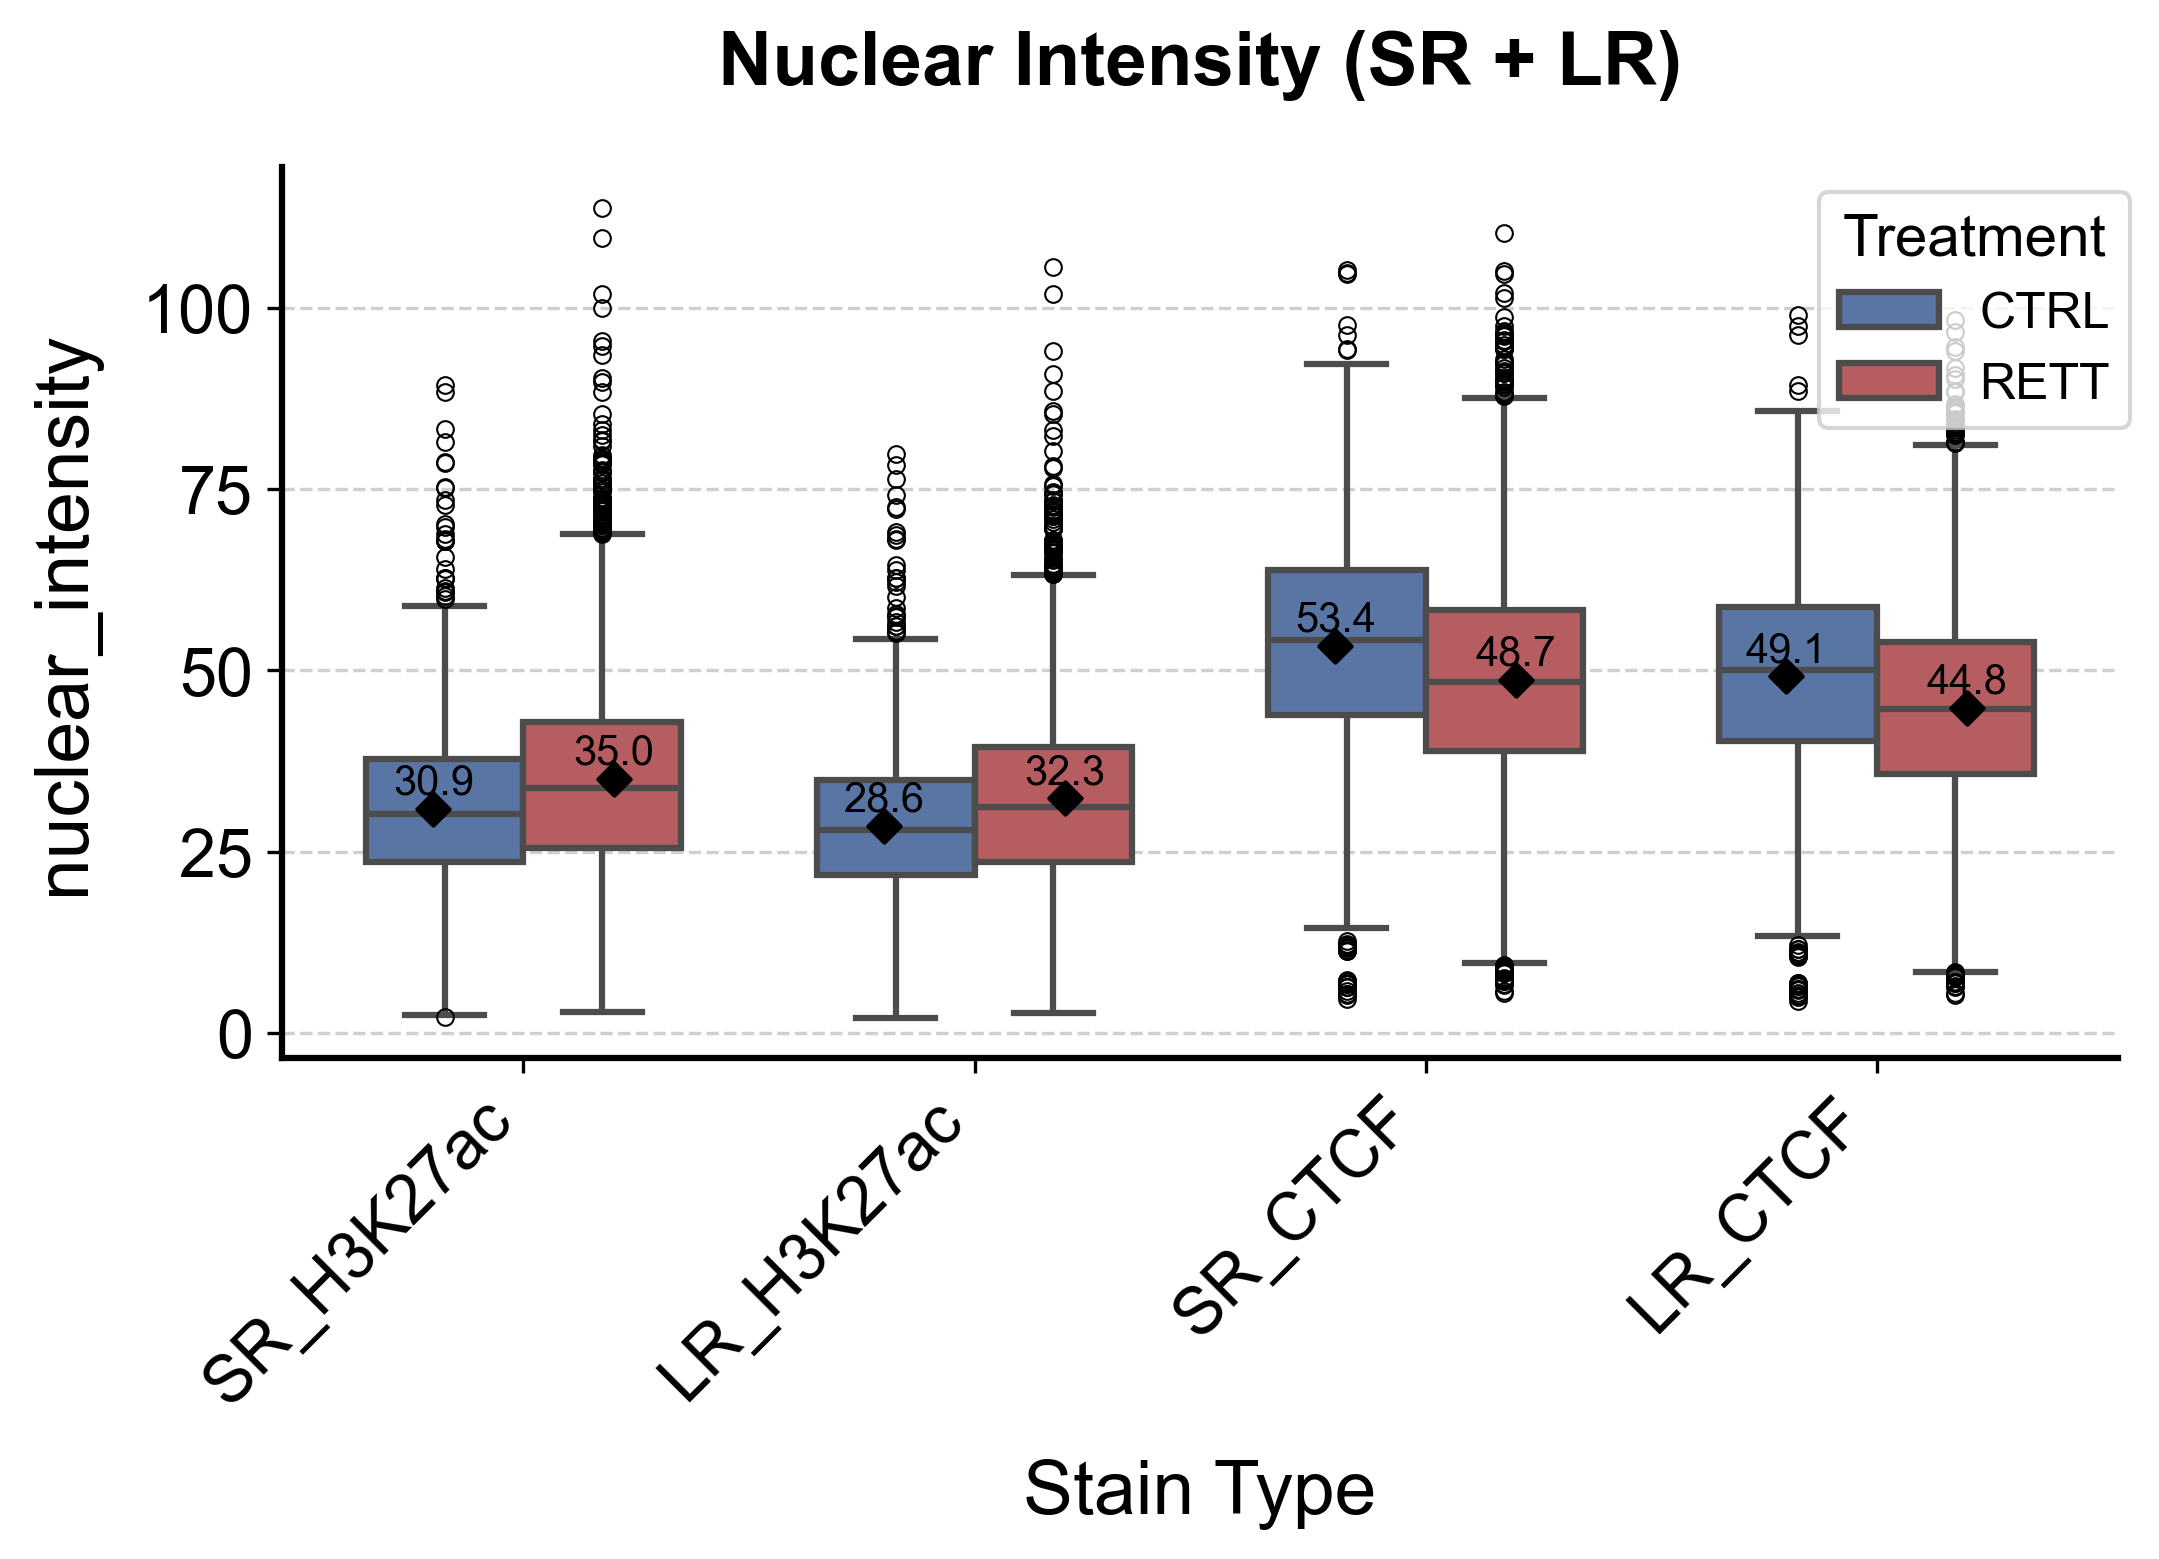

In [61]:
savepath = f"{homepath}/results_RTT/Biomarker/results_figures"
savetitle = {
    'chromatin_num': 'Puncta Number',
    'chromatin_area': 'Puncta Area',
    'chromatin_shape': 'Puncta Shape Irregularity',
    'chromatin_intensity': 'Puncta Intensity',
    'chromatin_distribution_part5': 'Puncta Periphery Enrichment',
    'nuclear_intensity': 'Nuclear Intensity'
}

for feature in ['chromatin_num', 'chromatin_area', 'chromatin_shape',
                'chromatin_intensity', 'chromatin_distribution_part5', 'nuclear_intensity']:
    print(f"\n=== Feature: {feature} ===")
    print(calculate_ttest_pvalues(data_all, group_col='Stain_Type',
                                  condition_col='State', value_col=feature))
    validata_boxplot_grouped(data_all, feature, savepath, rett="RETT")